# 03. Feature Selection

## Feature Selection for CIC-IDS2017 Network Intrusion Detection

Feature selection is an important stage in the machine learning pipeline because it identifies the most relevant features from the preprocessed dataset while reducing unnecessary, redundant, or less informative variables.

In the previous preprocessing stage, the CIC-IDS2017 dataset was cleaned, divided into training and testing datasets, processed using training-derived IQR boundaries, filtered using correlation analysis, and standardized using a `StandardScaler` fitted only on the training data.

As a result, the preprocessing stage produced:

- **Training samples:** 894,944
- **Testing samples:** 223,737
- **Input features:** 37
- **Target classes:** 4

The objective of this notebook is to further analyze these 37 features and identify a smaller set of informative features that can be used for machine learning model development.

### Feature Selection Techniques

The following feature-selection techniques will be considered in this notebook:

1. **Variance-based feature selection**  
   Identifies features with very little variation across the training observations.

2. **Correlation-based feature selection**  
   Identifies remaining highly correlated features that may contain redundant information.

3. **Model-based feature selection**  
   Uses a machine learning model to evaluate the relative importance of the remaining features and identify the most informative variables.

The feature-selection process will be performed using the **training dataset** to prevent information leakage.

After the final feature set has been determined, the same selected features will be applied to the testing dataset.

### Data Leakage Prevention

Data-dependent feature-selection decisions will be learned from the **training data only**.

The testing dataset will not be used to determine:

- Variance thresholds.
- Correlation thresholds or feature-removal decisions.
- Model-based feature importance.
- The final selected feature set.

Once the final feature set has been determined from the training data, the same feature selection will be applied to the testing data.

This ensures that the held-out testing data does not influence the feature-selection process.

### Notebook Objective

The main objective of this notebook is to reduce the dimensionality of the preprocessed CIC-IDS2017 dataset while retaining features that are useful for distinguishing between the different network traffic classes.

The final selected feature datasets will be saved for use in the subsequent **Model Building** stage.

In [1]:
# Feature Selection Notebook
# CIC-IDS2017 Network Intrusion Detection

print("FEATURE SELECTION NOTEBOOK")
print("=" * 60)
print("CIC-IDS2017 Network Intrusion Detection")
print("\nStarting feature selection process...")

FEATURE SELECTION NOTEBOOK
CIC-IDS2017 Network Intrusion Detection

Starting feature selection process...


## 2. Import Required Libraries

The required Python libraries are imported for performing feature-selection, data analysis, numerical computation, visualization, and dataset processing.

The main libraries used in this notebook are:

- **Pandas** — loading and manipulating tabular datasets.
- **NumPy** — numerical operations and array-based calculations.
- **Matplotlib** — creating visualizations.
- **Seaborn** — statistical visualization and correlation analysis.
- **Scikit-learn** — applying feature-selection techniques and machine-learning utilities.

These libraries provide the necessary functionality for analyzing the preprocessed CIC-IDS2017 dataset and identifying informative features.

No feature-selection operation is performed in this section. The libraries are only imported and verified for use in the subsequent sections.

In [2]:
# Import required libraries for feature selection

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold

print("All required libraries imported successfully!")

All required libraries imported successfully!


## 3. Define File Paths

The preprocessed training and testing datasets generated in the previous preprocessing stage are stored in the `data/processed` directory.

This section defines the file paths required to load the following datasets:

- `X_train.csv` — preprocessed training features.
- `X_test.csv` — preprocessed testing features.
- `y_train.csv` — training target labels.
- `y_test.csv` — testing target labels.

The paths are defined separately so that the datasets can be loaded consistently throughout the feature-selection pipeline.

The feature-selection process will use the training dataset to learn all data-dependent decisions, while the same decisions will later be applied to the testing dataset.

In [3]:
# Define paths to the preprocessed datasets

processed_dir = "../data/processed"

X_train_path = os.path.join(processed_dir, "X_train.csv")
X_test_path = os.path.join(processed_dir, "X_test.csv")
y_train_path = os.path.join(processed_dir, "y_train.csv")
y_test_path = os.path.join(processed_dir, "y_test.csv")

print("Processed data directory:", processed_dir)
print("\nInput file paths:")
print("X_train:", X_train_path)
print("X_test :", X_test_path)
print("y_train:", y_train_path)
print("y_test :", y_test_path)

Processed data directory: ../data/processed

Input file paths:
X_train: ../data/processed/X_train.csv
X_test : ../data/processed/X_test.csv
y_train: ../data/processed/y_train.csv
y_test : ../data/processed/y_test.csv


## 4. Verify Input Files

Before loading the datasets, the existence of each required input file is verified.

The feature-selection notebook depends on four files generated during preprocessing:

- `X_train.csv`
- `X_test.csv`
- `y_train.csv`
- `y_test.csv`

Checking the files before loading helps identify incorrect paths or missing preprocessing outputs at an early stage.

All four files must be available before continuing with the feature-selection process.

In [4]:
# Verify that all required input files exist

input_files = {
    "X_train": X_train_path,
    "X_test": X_test_path,
    "y_train": y_train_path,
    "y_test": y_test_path
}

print("Checking required input files...")
print("=" * 60)

all_files_exist = True

for name, path in input_files.items():
    exists = os.path.exists(path)
    
    if exists:
        print(f"{name:<8}: FOUND")
    else:
        print(f"{name:<8}: NOT FOUND")
        all_files_exist = False

print("=" * 60)

if all_files_exist:
    print("All required input files are available.")
else:
    print("One or more required input files are missing.")

Checking required input files...
X_train : FOUND
X_test  : FOUND
y_train : FOUND
y_test  : FOUND
All required input files are available.


## 5. Load Training Features

The preprocessed training feature dataset is loaded from `X_train.csv`.

The training feature dataset contains the input variables that will be used throughout the feature-selection process.

According to the preprocessing stage, the training dataset contains:

- **894,944 training observations**
- **37 preprocessed features**

The features have already undergone the required preprocessing steps, including missing-value handling, outlier treatment, training-based correlation filtering, and standardization.

This dataset will be used as the primary dataset for learning feature-selection decisions.

In [5]:
# Load the preprocessed training feature dataset

X_train = pd.read_csv(X_train_path)

print("Training feature dataset loaded successfully!")
print("=" * 60)
print("Shape of X_train:", X_train.shape)
print("Number of training samples:", X_train.shape[0])
print("Number of features:", X_train.shape[1])

Training feature dataset loaded successfully!
Shape of X_train: (894944, 37)
Number of training samples: 894944
Number of features: 37


## 6. Load Testing Features

The preprocessed testing feature dataset is loaded from `X_test.csv`.

The testing dataset contains the same feature columns as the training dataset and is reserved for later evaluation.

According to the preprocessing stage, the testing dataset contains:

- **223,737 testing observations**
- **37 preprocessed features**

The testing data will not be used to learn any feature-selection decisions. Instead, after feature selection has been learned from the training data, the same selected feature columns will be applied to the testing dataset.

This approach preserves the independence of the held-out testing data and helps prevent data leakage.

In [6]:
# Load the preprocessed testing feature dataset

X_test = pd.read_csv(X_test_path)

print("Testing feature dataset loaded successfully!")
print("=" * 60)
print("Shape of X_test:", X_test.shape)
print("Number of testing samples:", X_test.shape[0])
print("Number of features:", X_test.shape[1])

Testing feature dataset loaded successfully!
Shape of X_test: (223737, 37)
Number of testing samples: 223737
Number of features: 37


## 7. Load Training Target

The training target labels are loaded from `y_train.csv`.

The target variable represents the network traffic class associated with each training observation.

The training target contains **894,944 labels**, corresponding to the 894,944 observations in `X_train`.

These labels are required for the model-based feature-selection stage, where a machine-learning model will learn the relationship between the input features and the target classes.

The target labels are kept separate from the feature dataset to maintain a clear distinction between input variables and the prediction target.

In [7]:
# Load the training target labels

y_train = pd.read_csv(y_train_path)

print("Training target dataset loaded successfully!")
print("=" * 60)
print("Shape of y_train:", y_train.shape)
print("Number of training labels:", len(y_train))
print("\nTarget column:")
print(y_train.columns.tolist())

Training target dataset loaded successfully!
Shape of y_train: (894944, 1)
Number of training labels: 894944

Target column:
['Target_Encoded']


## 8. Load Testing Target

The testing target labels are loaded from `y_test.csv`.

The target variable is stored in the `Target_Encoded` column and represents the encoded network traffic class associated with each testing observation.

The testing target contains **223,737 labels**, corresponding to the 223,737 observations in `X_test`.

The testing target will be kept separate from the feature-selection learning process. It will only be used later to maintain the correct correspondence between the selected testing features and their target labels.

No feature-selection decision will be learned from the testing target.

In [8]:
# Load the testing target labels

y_test = pd.read_csv(y_test_path)

print("Testing target dataset loaded successfully!")
print("=" * 60)
print("Shape of y_test:", y_test.shape)
print("Number of testing labels:", len(y_test))
print("\nTarget column:")
print(y_test.columns.tolist())

Testing target dataset loaded successfully!
Shape of y_test: (223737, 1)
Number of testing labels: 223737

Target column:
['Target_Encoded']


## 9. Verify Loaded Dataset Shapes

The shapes of all four loaded datasets are verified together.

The expected dimensions are:

- `X_train`: 894,944 observations × 37 features
- `X_test`: 223,737 observations × 37 features
- `y_train`: 894,944 target labels
- `y_test`: 223,737 target labels

The number of observations in each feature dataset must match the number of corresponding target labels.

This verification ensures that the training and testing datasets were loaded correctly before beginning feature selection.

In [9]:
# Verify the shapes of all loaded datasets

print("DATASET SHAPE VERIFICATION")
print("=" * 60)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

print("\nAlignment checks:")
print("X_train and y_train samples match:",
      X_train.shape[0] == y_train.shape[0])

print("X_test and y_test samples match:",
      X_test.shape[0] == y_test.shape[0])

print("Training and testing feature counts match:",
      X_train.shape[1] == X_test.shape[1])

DATASET SHAPE VERIFICATION
X_train shape : (894944, 37)
X_test shape  : (223737, 37)
y_train shape : (894944, 1)
y_test shape  : (223737, 1)

Alignment checks:
X_train and y_train samples match: True
X_test and y_test samples match: True
Training and testing feature counts match: True


## 10. Inspect Feature Names

The feature names contained in the preprocessed training dataset are inspected before applying feature-selection techniques.

The feature names identify the network traffic characteristics available to the machine-learning models.

At this stage, the dataset contains **37 features**. The target variable is stored separately in `y_train` and is therefore not included among these feature columns.

Inspecting the feature names provides a clear reference for tracking which features are retained or removed during each feature-selection stage.

In [10]:
# Display the feature names

feature_names = X_train.columns.tolist()

print("FEATURE NAMES")
print("=" * 60)
print("Total number of features:", len(feature_names))
print("\nFeature list:")

for index, feature in enumerate(feature_names, start=1):
    print(f"{index:2d}. {feature}")

FEATURE NAMES
Total number of features: 37

Feature list:
 1. Destination Port
 2. Flow Duration
 3. Total Fwd Packets
 4. Total Backward Packets
 5. Total Length of Fwd Packets
 6. Total Length of Bwd Packets
 7. Fwd Packet Length Min
 8. Fwd Packet Length Mean
 9. Fwd Packet Length Std
10. Bwd Packet Length Min
11. Flow Bytes/s
12. Flow Packets/s
13. Flow IAT Min
14. Fwd IAT Min
15. Bwd IAT Total
16. Bwd IAT Min
17. Fwd PSH Flags
18. Bwd Packets/s
19. FIN Flag Count
20. SYN Flag Count
21. RST Flag Count
22. PSH Flag Count
23. ACK Flag Count
24. URG Flag Count
25. ECE Flag Count
26. Down/Up Ratio
27. Init_Win_bytes_forward
28. Init_Win_bytes_backward
29. min_seg_size_forward
30. Active Mean
31. Active Std
32. Active Max
33. Active Min
34. Idle Mean
35. Idle Std
36. Idle Max
37. Idle Min


## 11. Verify Train/Test Feature Consistency

Before performing feature selection, the feature columns of the training and testing datasets are compared.

For a valid machine-learning pipeline, the training and testing datasets must contain:

- The same number of features.
- The same feature names.
- The same feature order.

This consistency is essential because feature-selection decisions will be learned from the training dataset and then applied to the testing dataset using the exact same selected feature columns.

If the feature sets differ, applying the training-based feature-selection results to the testing data could produce incorrect or misaligned inputs.

Therefore, both the feature count and the complete ordered feature list are verified in this section.

In [11]:
# Verify that training and testing feature columns are identical

train_features = X_train.columns.tolist()
test_features = X_test.columns.tolist()

same_feature_count = X_train.shape[1] == X_test.shape[1]
same_feature_names = set(train_features) == set(test_features)
same_feature_order = train_features == test_features

print("TRAIN/TEST FEATURE CONSISTENCY CHECK")
print("=" * 60)

print("Same number of features :", same_feature_count)
print("Same feature names      :", same_feature_names)
print("Same feature order      :", same_feature_order)

print("\nTraining feature count:", len(train_features))
print("Testing feature count :", len(test_features))

if same_feature_count and same_feature_names and same_feature_order:
    print("\nFeature consistency check PASSED.")
else:
    print("\nFeature consistency check FAILED.")

TRAIN/TEST FEATURE CONSISTENCY CHECK
Same number of features : True
Same feature names      : True
Same feature order      : True

Training feature count: 37
Testing feature count : 37

Feature consistency check PASSED.


## 12. Verify Target Classes

The unique target classes in the training and testing datasets are examined to confirm that both datasets contain the same classification categories.

The CIC-IDS2017 dataset used in this project contains four encoded network traffic classes.

The target labels are stored in the `Target_Encoded` column.

The same set of target classes should be present in both the training and testing datasets because a consistent classification problem must be maintained across the two datasets.

This verification is performed before feature selection to ensure that the target labels are correctly loaded and aligned with the preprocessed feature datasets.

In [12]:
# Verify unique target classes

train_classes = sorted(y_train["Target_Encoded"].unique().tolist())
test_classes = sorted(y_test["Target_Encoded"].unique().tolist())

print("TARGET CLASS VERIFICATION")
print("=" * 60)

print("Training target classes:", train_classes)
print("Testing target classes :", test_classes)

print("\nNumber of training classes:", len(train_classes))
print("Number of testing classes :", len(test_classes))

print("\nSame target classes:",
      train_classes == test_classes)

TARGET CLASS VERIFICATION
Training target classes: [0, 1, 2, 3]
Testing target classes : [0, 1, 2, 3]

Number of training classes: 4
Number of testing classes : 4

Same target classes: True


## 13. Analyze Target Class Distribution

The distribution of the target classes is analyzed separately for the training and testing datasets.

Class distribution analysis is important because network intrusion datasets commonly contain a substantial imbalance between normal traffic and different attack categories.

Understanding the number and proportion of observations belonging to each target class helps identify whether the training and testing datasets preserve a similar class distribution after the preprocessing and stratified splitting stages.

The analysis includes:

- Number of observations in each class.
- Percentage of observations represented by each class.
- Comparison of the class distribution between training and testing datasets.

The target distribution is analyzed for descriptive purposes only. No feature-selection decision will be based on the testing class distribution.

In [13]:
# Analyze target class distribution

train_distribution = y_train["Target_Encoded"].value_counts().sort_index()
test_distribution = y_test["Target_Encoded"].value_counts().sort_index()

train_percentage = (train_distribution / len(y_train) * 100).round(2)
test_percentage = (test_distribution / len(y_test) * 100).round(2)

class_distribution = pd.DataFrame({
    "Training Count": train_distribution,
    "Training Percentage": train_percentage,
    "Testing Count": test_distribution,
    "Testing Percentage": test_percentage
})

print("TARGET CLASS DISTRIBUTION")
print("=" * 80)
print(class_distribution)

TARGET CLASS DISTRIBUTION
                Training Count  Training Percentage  Testing Count  \
Target_Encoded                                                       
0                       718314                80.26         179579   
1                         1562                 0.17            391   
2                       102413                11.44          25603   
3                        72655                 8.12          18164   

                Testing Percentage  
Target_Encoded                      
0                            80.26  
1                             0.17  
2                            11.44  
3                             8.12  


## 14. Check Missing Values

The training and testing feature datasets are checked for missing values before applying feature-selection techniques.

Missing values can interfere with statistical calculations and machine-learning algorithms. Therefore, the preprocessed datasets should contain no missing values at this stage.

The check is performed separately for the training and testing feature datasets.

A successful preprocessing pipeline should result in:

- Zero missing values in `X_train`.
- Zero missing values in `X_test`.

This section is a validation step only. No missing-value imputation or other transformation is performed here.

In [14]:
# Check for missing values in training and testing features

train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()

print("MISSING VALUE CHECK")
print("=" * 60)

print("Missing values in X_train:", train_missing)
print("Missing values in X_test :", test_missing)

if train_missing == 0 and test_missing == 0:
    print("\nMissing-value check PASSED.")
else:
    print("\nMissing-value check FAILED.")

MISSING VALUE CHECK
Missing values in X_train: 0
Missing values in X_test : 0

Missing-value check PASSED.


## 15. Check Infinite Values

The training and testing feature datasets are checked for positive and negative infinite values.

Infinite values can occur in network traffic datasets when a feature involves division by a value that can become zero. Such values can cause problems during statistical analysis, feature selection, and machine-learning model training.

The preprocessed datasets should therefore contain no infinite values.

This section verifies:

- The total number of positive or negative infinite values in `X_train`.
- The total number of positive or negative infinite values in `X_test`.

No replacement or transformation is performed in this section because the purpose is only to validate the quality of the already preprocessed datasets.

In [15]:
# Check for infinite values in training and testing features

train_infinite = np.isinf(X_train.to_numpy()).sum()
test_infinite = np.isinf(X_test.to_numpy()).sum()

print("INFINITE VALUE CHECK")
print("=" * 60)

print("Infinite values in X_train:", train_infinite)
print("Infinite values in X_test :", test_infinite)

if train_infinite == 0 and test_infinite == 0:
    print("\nInfinite-value check PASSED.")
else:
    print("\nInfinite-value check FAILED.")

INFINITE VALUE CHECK
Infinite values in X_train: 0
Infinite values in X_test : 0

Infinite-value check PASSED.


## 16. Verify Feature Data Types

The data types of all feature columns are examined to ensure that the preprocessed datasets contain numerical values.

The feature-selection techniques used in this notebook, including variance analysis, correlation analysis, and model-based feature selection, require numerical feature values.

Therefore, all columns in `X_train` and `X_test` should have numerical data types.

This section verifies:

- The data type of each training feature.
- The data type of each testing feature.
- Whether any non-numeric feature columns are present.

No data-type conversion is performed in this section because the preprocessing stage is expected to have already produced numerical feature data.

In [16]:
# Verify that all feature columns are numeric

train_non_numeric = X_train.select_dtypes(exclude=np.number).columns.tolist()
test_non_numeric = X_test.select_dtypes(exclude=np.number).columns.tolist()

print("FEATURE DATA TYPE VERIFICATION")
print("=" * 60)

print("Total training features:", X_train.shape[1])
print("Total testing features :", X_test.shape[1])

print("\nNon-numeric training features:", len(train_non_numeric))
print("Non-numeric testing features :", len(test_non_numeric))

if train_non_numeric:
    print("\nTraining non-numeric columns:")
    print(train_non_numeric)

if test_non_numeric:
    print("\nTesting non-numeric columns:")
    print(test_non_numeric)

if len(train_non_numeric) == 0 and len(test_non_numeric) == 0:
    print("\nAll feature columns are numeric.")
    print("Data type verification PASSED.")
else:
    print("\nData type verification FAILED.")

FEATURE DATA TYPE VERIFICATION
Total training features: 37
Total testing features : 37

Non-numeric training features: 0
Non-numeric testing features : 0

All feature columns are numeric.
Data type verification PASSED.


## 17. Create Feature Selection Copies

Working copies of the preprocessed training and testing feature datasets are created for the feature-selection process.

The original `X_train` and `X_test` datasets are preserved as reference datasets.

The working datasets will be modified progressively as different feature-selection techniques are applied:

1. Variance-based filtering.
2. Correlation-based filtering.
3. Model-based feature selection.

Only the training data will be used to learn feature-selection decisions. The corresponding decisions will then be applied to the testing data.

Creating separate working copies makes the feature-selection process easier to track while preserving the original preprocessed datasets.

In [17]:
# Create working copies for feature selection

X_train_fs = X_train.copy()
X_test_fs = X_test.copy()

print("Feature-selection working datasets created successfully!")
print("=" * 60)
print("X_train_fs shape:", X_train_fs.shape)
print("X_test_fs shape :", X_test_fs.shape)

print("\nOriginal datasets remain unchanged:")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

Feature-selection working datasets created successfully!
X_train_fs shape: (894944, 37)
X_test_fs shape : (223737, 37)

Original datasets remain unchanged:
X_train shape: (894944, 37)
X_test shape : (223737, 37)


## 18. Record Initial Feature Set

The initial feature set is recorded before applying any feature-selection technique.

At the beginning of the feature-selection process, the preprocessed training and testing datasets contain **37 features**.

The feature names are stored in a separate list so that the changes made during each feature-selection stage can be tracked systematically.

This initial feature set serves as the baseline for measuring dimensionality reduction after:

1. Variance-based filtering.
2. Correlation-based filtering.
3. Model-based feature selection.

The target variable is not included in the feature set because it is stored separately in `y_train` and `y_test`.

In [18]:
# Record the initial feature set

initial_features = X_train_fs.columns.tolist()
initial_feature_count = len(initial_features)

print("INITIAL FEATURE SET")
print("=" * 60)

print("Initial number of features:", initial_feature_count)

print("\nInitial features:")
for index, feature in enumerate(initial_features, start=1):
    print(f"{index:2d}. {feature}")

INITIAL FEATURE SET
Initial number of features: 37

Initial features:
 1. Destination Port
 2. Flow Duration
 3. Total Fwd Packets
 4. Total Backward Packets
 5. Total Length of Fwd Packets
 6. Total Length of Bwd Packets
 7. Fwd Packet Length Min
 8. Fwd Packet Length Mean
 9. Fwd Packet Length Std
10. Bwd Packet Length Min
11. Flow Bytes/s
12. Flow Packets/s
13. Flow IAT Min
14. Fwd IAT Min
15. Bwd IAT Total
16. Bwd IAT Min
17. Fwd PSH Flags
18. Bwd Packets/s
19. FIN Flag Count
20. SYN Flag Count
21. RST Flag Count
22. PSH Flag Count
23. ACK Flag Count
24. URG Flag Count
25. ECE Flag Count
26. Down/Up Ratio
27. Init_Win_bytes_forward
28. Init_Win_bytes_backward
29. min_seg_size_forward
30. Active Mean
31. Active Std
32. Active Max
33. Active Min
34. Idle Mean
35. Idle Std
36. Idle Max
37. Idle Min


## 19. Analyze Feature Variance

Variance measures how much the values of a feature differ across the observations.

A feature with very low variance has nearly the same value for most observations and may provide limited discriminatory information for a machine-learning model.

In this stage, the variance of each feature is calculated using the **training dataset only**.

The testing dataset is not used to determine which features have low variance. This prevents information from the held-out testing data from influencing the feature-selection process.

The calculated variances will be inspected before defining the variance threshold.

Because the current dataset has already been standardized during preprocessing, most informative non-constant features are expected to have substantial variance, while constant or near-constant features may have very low variance.

In [19]:
# Calculate feature variance using the training dataset only

feature_variances = X_train_fs.var()

variance_summary = pd.DataFrame({
    "Feature": feature_variances.index,
    "Variance": feature_variances.values
})

variance_summary = variance_summary.sort_values(
    by="Variance",
    ascending=True
).reset_index(drop=True)

print("FEATURE VARIANCE ANALYSIS")
print("=" * 70)

print("Number of features analyzed:", len(variance_summary))

print("\nFeatures with the lowest variance:")
print(variance_summary.head(10).to_string(index=False))

print("\nFeatures with the highest variance:")
print(variance_summary.tail(10).sort_values(
    by="Variance",
    ascending=False
).to_string(index=False))

FEATURE VARIANCE ANALYSIS
Number of features analyzed: 37

Features with the lowest variance:
       Feature  Variance
ECE Flag Count       0.0
    Active Max       0.0
    Active Std       0.0
URG Flag Count       0.0
RST Flag Count       0.0
SYN Flag Count       0.0
FIN Flag Count       0.0
   Active Mean       0.0
 Fwd PSH Flags       0.0
      Idle Std       0.0

Features with the highest variance:
                    Feature  Variance
                Fwd IAT Min  1.000001
      Bwd Packet Length Min  1.000001
     Total Backward Packets  1.000001
                Bwd IAT Min  1.000001
Total Length of Bwd Packets  1.000001
           Destination Port  1.000001
      Fwd Packet Length Std  1.000001
     Init_Win_bytes_forward  1.000001
          Total Fwd Packets  1.000001
              Flow Duration  1.000001


## 20. Identify Zero-Variance Features

Based on the variance analysis, the features with a variance of exactly zero are identified.

A zero-variance feature has the same value for every observation in the training dataset. Since such a feature provides no variation, it cannot help a machine-learning model distinguish between different observations.

These features are therefore candidates for removal during variance-based feature selection.

The identification is performed using the **training dataset only**.

The zero-variance features will be removed from both the training and testing datasets using the feature-selection decision learned from the training data.

This ensures that the testing dataset remains completely independent of the feature-selection decision.

In [20]:
# Identify zero-variance features in the training dataset

zero_variance_features = feature_variances[
    feature_variances == 0
].index.tolist()

print("ZERO-VARIANCE FEATURE ANALYSIS")
print("=" * 70)

print("Number of zero-variance features:", len(zero_variance_features))

print("\nZero-variance features:")

if zero_variance_features:
    for index, feature in enumerate(zero_variance_features, start=1):
        print(f"{index:2d}. {feature}")
else:
    print("No zero-variance features found.")

ZERO-VARIANCE FEATURE ANALYSIS
Number of zero-variance features: 14

Zero-variance features:
 1. Fwd PSH Flags
 2. FIN Flag Count
 3. SYN Flag Count
 4. RST Flag Count
 5. URG Flag Count
 6. ECE Flag Count
 7. Active Mean
 8. Active Std
 9. Active Max
10. Active Min
11. Idle Mean
12. Idle Std
13. Idle Max
14. Idle Min


## 21. Define Variance Selection Threshold

Based on the variance analysis, several features were found to have exactly zero variance.

A variance threshold of **0** is therefore selected for the first feature-selection stage.

Using a threshold of zero removes only features whose variance is exactly zero, while retaining all features that contain some variation.

This is appropriate for the current preprocessed dataset because the features were standardized during preprocessing. As a result, non-constant features have variance close to 1, while constant features have variance equal to 0.

The threshold is learned and applied using the training dataset only.

The same retained feature names will subsequently be applied to the testing dataset.

In [21]:
# Define the variance threshold for feature selection

variance_threshold = 0.0

print("VARIANCE THRESHOLD")
print("=" * 60)

print("Selected variance threshold:", variance_threshold)
print("Features with variance <= threshold will be removed.")
print("Features with variance > threshold will be retained.")

VARIANCE THRESHOLD
Selected variance threshold: 0.0
Features with variance <= threshold will be removed.
Features with variance > threshold will be retained.


## 22. Apply Variance Threshold to Training Data

The `VarianceThreshold` method from Scikit-learn is applied to the training feature dataset using the threshold defined in the previous section.

The selector is fitted **only on `X_train_fs`**.

Since the selected threshold is `0.0`, features with zero variance are removed, while features with variance greater than zero are retained.

The feature names retained by the selector are extracted so that the same feature-selection decision can be applied to the testing dataset.

At this stage, the testing dataset is not used to determine which features should be removed.

The number of retained and removed features will be recorded to measure the dimensionality reduction achieved by variance-based feature selection.

In [22]:
# Apply VarianceThreshold to the training dataset

variance_selector = VarianceThreshold(
    threshold=variance_threshold
)

variance_selector.fit(X_train_fs)

variance_support = variance_selector.get_support()

variance_selected_features = X_train_fs.columns[
    variance_support
].tolist()

variance_removed_features = X_train_fs.columns[
    ~variance_support
].tolist()

print("VARIANCE-BASED FEATURE SELECTION")
print("=" * 70)

print("Initial number of features :", X_train_fs.shape[1])
print("Retained features          :", len(variance_selected_features))
print("Removed features           :", len(variance_removed_features))

print("\nRetained features:")
for index, feature in enumerate(variance_selected_features, start=1):
    print(f"{index:2d}. {feature}")

print("\nRemoved features:")
for index, feature in enumerate(variance_removed_features, start=1):
    print(f"{index:2d}. {feature}")

VARIANCE-BASED FEATURE SELECTION
Initial number of features : 37
Retained features          : 23
Removed features           : 14

Retained features:
 1. Destination Port
 2. Flow Duration
 3. Total Fwd Packets
 4. Total Backward Packets
 5. Total Length of Fwd Packets
 6. Total Length of Bwd Packets
 7. Fwd Packet Length Min
 8. Fwd Packet Length Mean
 9. Fwd Packet Length Std
10. Bwd Packet Length Min
11. Flow Bytes/s
12. Flow Packets/s
13. Flow IAT Min
14. Fwd IAT Min
15. Bwd IAT Total
16. Bwd IAT Min
17. Bwd Packets/s
18. PSH Flag Count
19. ACK Flag Count
20. Down/Up Ratio
21. Init_Win_bytes_forward
22. Init_Win_bytes_backward
23. min_seg_size_forward

Removed features:
 1. Fwd PSH Flags
 2. FIN Flag Count
 3. SYN Flag Count
 4. RST Flag Count
 5. URG Flag Count
 6. ECE Flag Count
 7. Active Mean
 8. Active Std
 9. Active Max
10. Active Min
11. Idle Mean
12. Idle Std
13. Idle Max
14. Idle Min


## 23. Create Variance-Selected Training Dataset

The retained features identified by the variance-based selection stage are used to create a reduced training feature dataset.

Only the feature columns retained by `VarianceThreshold` are kept.

The resulting dataset contains the original training observations but fewer input features.

The target variable is not modified because feature selection affects only the input variables.

This reduced training dataset will be used as the input for the next feature-selection stage.

The feature names are preserved so that the same feature subset can be applied consistently to the testing dataset.

In [23]:
# Create the variance-selected training dataset

X_train_variance = X_train_fs[
    variance_selected_features
].copy()

print("VARIANCE-SELECTED TRAINING DATASET")
print("=" * 70)

print("Original training shape        :", X_train_fs.shape)
print("After variance selection       :", X_train_variance.shape)

print("\nNumber of retained features:", X_train_variance.shape[1])
print("Number of removed features :", X_train_fs.shape[1] - X_train_variance.shape[1])

print("\nVariance-selected training dataset created successfully.")

VARIANCE-SELECTED TRAINING DATASET
Original training shape        : (894944, 37)
After variance selection       : (894944, 23)

Number of retained features: 23
Number of removed features : 14

Variance-selected training dataset created successfully.


## 24. Apply Variance Selection to Testing Data

The feature-selection decision learned from the training dataset is now applied to the testing dataset.

The 23 feature names retained during the training variance-selection stage are used to select the corresponding columns from `X_test_fs`.

The `VarianceThreshold` selector is not fitted again on the testing dataset.

This is important because the testing dataset must remain independent from the feature-selection learning process.

The testing dataset should therefore contain the same 23 features, in the same order, as the variance-selected training dataset.

This ensures that the training and testing datasets remain compatible for subsequent feature-selection and machine-learning stages.

In [24]:
# Apply the training-based variance selection to the testing dataset

X_test_variance = X_test_fs[
    variance_selected_features
].copy()

print("VARIANCE-SELECTED TESTING DATASET")
print("=" * 70)

print("Original testing shape          :", X_test_fs.shape)
print("After variance selection        :", X_test_variance.shape)

print("\nNumber of retained features:", X_test_variance.shape[1])

print("\nTraining and testing feature counts match:",
      X_train_variance.shape[1] == X_test_variance.shape[1])

print("Feature order matches:",
      X_train_variance.columns.tolist() == X_test_variance.columns.tolist())

VARIANCE-SELECTED TESTING DATASET
Original testing shape          : (223737, 37)
After variance selection        : (223737, 23)

Number of retained features: 23

Training and testing feature counts match: True
Feature order matches: True


## 25. Verify Variance-Based Feature Selection

The result of the variance-based feature-selection stage is verified to ensure that the selection was applied correctly.

The following conditions are checked:

- The number of retained features is 23.
- The number of removed features is 14.
- All retained training features have variance greater than zero.
- The training and testing datasets contain the same retained features in the same order.

This verification confirms that the variance-based feature-selection stage was completed correctly before proceeding to the next feature-selection technique.

In [25]:
# Verify the variance-based feature-selection results

retained_variances = X_train_variance.var()

all_retained_have_variance = (retained_variances > 0).all()

variance_selection_valid = (
    len(variance_selected_features) == 23
    and len(variance_removed_features) == 14
    and all_retained_have_variance
    and X_train_variance.columns.tolist() == X_test_variance.columns.tolist()
)

print("VARIANCE SELECTION VERIFICATION")
print("=" * 70)

print("Initial feature count       :", len(initial_features))
print("Retained feature count      :", len(variance_selected_features))
print("Removed feature count       :", len(variance_removed_features))

print("\nAll retained features have variance > 0:",
      all_retained_have_variance)

print("Train/test feature order matches:",
      X_train_variance.columns.tolist() == X_test_variance.columns.tolist())

print("\nVariance selection verification:",
      "PASSED" if variance_selection_valid else "FAILED")

VARIANCE SELECTION VERIFICATION
Initial feature count       : 37
Retained feature count      : 23
Removed feature count       : 14

All retained features have variance > 0: True
Train/test feature order matches: True

Variance selection verification: PASSED


## 26. Prepare for Correlation-Based Feature Selection

After removing the 14 zero-variance features, 23 features remain in the dataset.

The next stage examines the relationships between these remaining features using **Pearson correlation**.

Correlation-based feature selection can identify features that contain highly similar information. When two features are strongly correlated, keeping both may introduce redundancy into the model input.

The correlation analysis will be performed using the **training dataset only**.

The testing dataset will not be used to calculate the correlation matrix or determine which features should be removed.

A correlation threshold will be defined after inspecting the training correlation matrix.

In [26]:
# Import tools required for correlation-based feature selection

print("CORRELATION ANALYSIS PREPARATION")
print("=" * 70)

print("Current training feature count:", X_train_variance.shape[1])
print("Current testing feature count :", X_test_variance.shape[1])

print("\nCorrelation analysis will be performed using training data only.")
print("Pearson correlation will be used.")

CORRELATION ANALYSIS PREPARATION
Current training feature count: 23
Current testing feature count : 23

Correlation analysis will be performed using training data only.
Pearson correlation will be used.


## 27. Calculate the Training Correlation Matrix

The Pearson correlation matrix is calculated for the 23 variance-selected features using the training dataset.

Pearson correlation measures the strength and direction of a linear relationship between two numerical features.

The correlation coefficient ranges from **-1 to +1**:

- A value close to **+1** indicates a strong positive linear relationship.
- A value close to **-1** indicates a strong negative linear relationship.
- A value close to **0** indicates little or no linear relationship.

The correlation matrix is calculated using **`X_train_variance` only**.

The testing dataset is not used to calculate the correlation matrix or determine feature-removal decisions.

The resulting matrix will be inspected to identify pairs of features with very strong correlations and possible redundancy.

In [27]:
# Calculate the Pearson correlation matrix using training data only

correlation_matrix = X_train_variance.corr(method="pearson")

print("TRAINING CORRELATION MATRIX")
print("=" * 70)

print("Correlation matrix shape:", correlation_matrix.shape)
print("Number of features analyzed:", correlation_matrix.shape[0])

print("\nCorrelation matrix:")
print(correlation_matrix.round(3).to_string())

TRAINING CORRELATION MATRIX
Correlation matrix shape: (23, 23)
Number of features analyzed: 23

Correlation matrix:
                             Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Min  Flow Bytes/s  Flow Packets/s  Flow IAT Min  Fwd IAT Min  Bwd IAT Total  Bwd IAT Min  Bwd Packets/s  PSH Flag Count  ACK Flag Count  Down/Up Ratio  Init_Win_bytes_forward  Init_Win_bytes_backward  min_seg_size_forward
Destination Port                        1.000         -0.180             -0.249                  -0.213                       -0.247                       -0.366                 -0.407                  -0.298                 -0.039                 -0.421         0.185           0.632        -0.065       -0.166         -0.148       -0.347          0.469          -0.005           0.510          0.026          

## 28. Identify Highly Correlated Feature Pairs

The training correlation matrix is examined to identify pairs of features with a strong linear relationship.

A feature pair is considered highly correlated when the **absolute Pearson correlation coefficient is greater than or equal to 0.90**.

The absolute value is used because both strong positive and strong negative correlations indicate a strong linear relationship between two features.

Only the upper triangle of the correlation matrix is examined so that each feature pair is reported only once.

This analysis is performed using the training dataset only.

The identified highly correlated pairs will be reviewed before deciding which features should be removed to reduce redundancy.

In [28]:
# Identify highly correlated feature pairs

correlation_threshold = 0.90

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_correlation_pairs = []

for column in upper_triangle.columns:
    for row in upper_triangle.index:
        correlation_value = upper_triangle.loc[row, column]

        if pd.notna(correlation_value) and abs(correlation_value) >= correlation_threshold:
            high_correlation_pairs.append({
                "Feature 1": row,
                "Feature 2": column,
                "Correlation": correlation_value
            })

high_correlation_pairs_df = pd.DataFrame(high_correlation_pairs)

if not high_correlation_pairs_df.empty:
    high_correlation_pairs_df = high_correlation_pairs_df.sort_values(
        by="Correlation",
        key=lambda x: x.abs(),
        ascending=False
    ).reset_index(drop=True)

print("HIGHLY CORRELATED FEATURE PAIRS")
print("=" * 80)

print("Correlation threshold:", correlation_threshold)
print("Number of highly correlated pairs:",
      len(high_correlation_pairs_df))

if not high_correlation_pairs_df.empty:
    print("\nHighly correlated feature pairs:")
    print(high_correlation_pairs_df.to_string(index=False))
else:
    print("\nNo highly correlated feature pairs found.")

HIGHLY CORRELATED FEATURE PAIRS
Correlation threshold: 0.9
Number of highly correlated pairs: 0

No highly correlated feature pairs found.


## 29. Visualize the Training Correlation Matrix

The Pearson correlation matrix of the 23 variance-selected training features is visualized using a heatmap.

A correlation heatmap provides a visual representation of the strength and direction of relationships between features.

The visualization helps confirm the numerical correlation analysis and provides an overview of the relationships among the retained features.

The heatmap is based exclusively on the training dataset.

Since no feature pair reached the selected absolute correlation threshold of 0.90, no additional feature removal is expected from this correlation-based analysis.

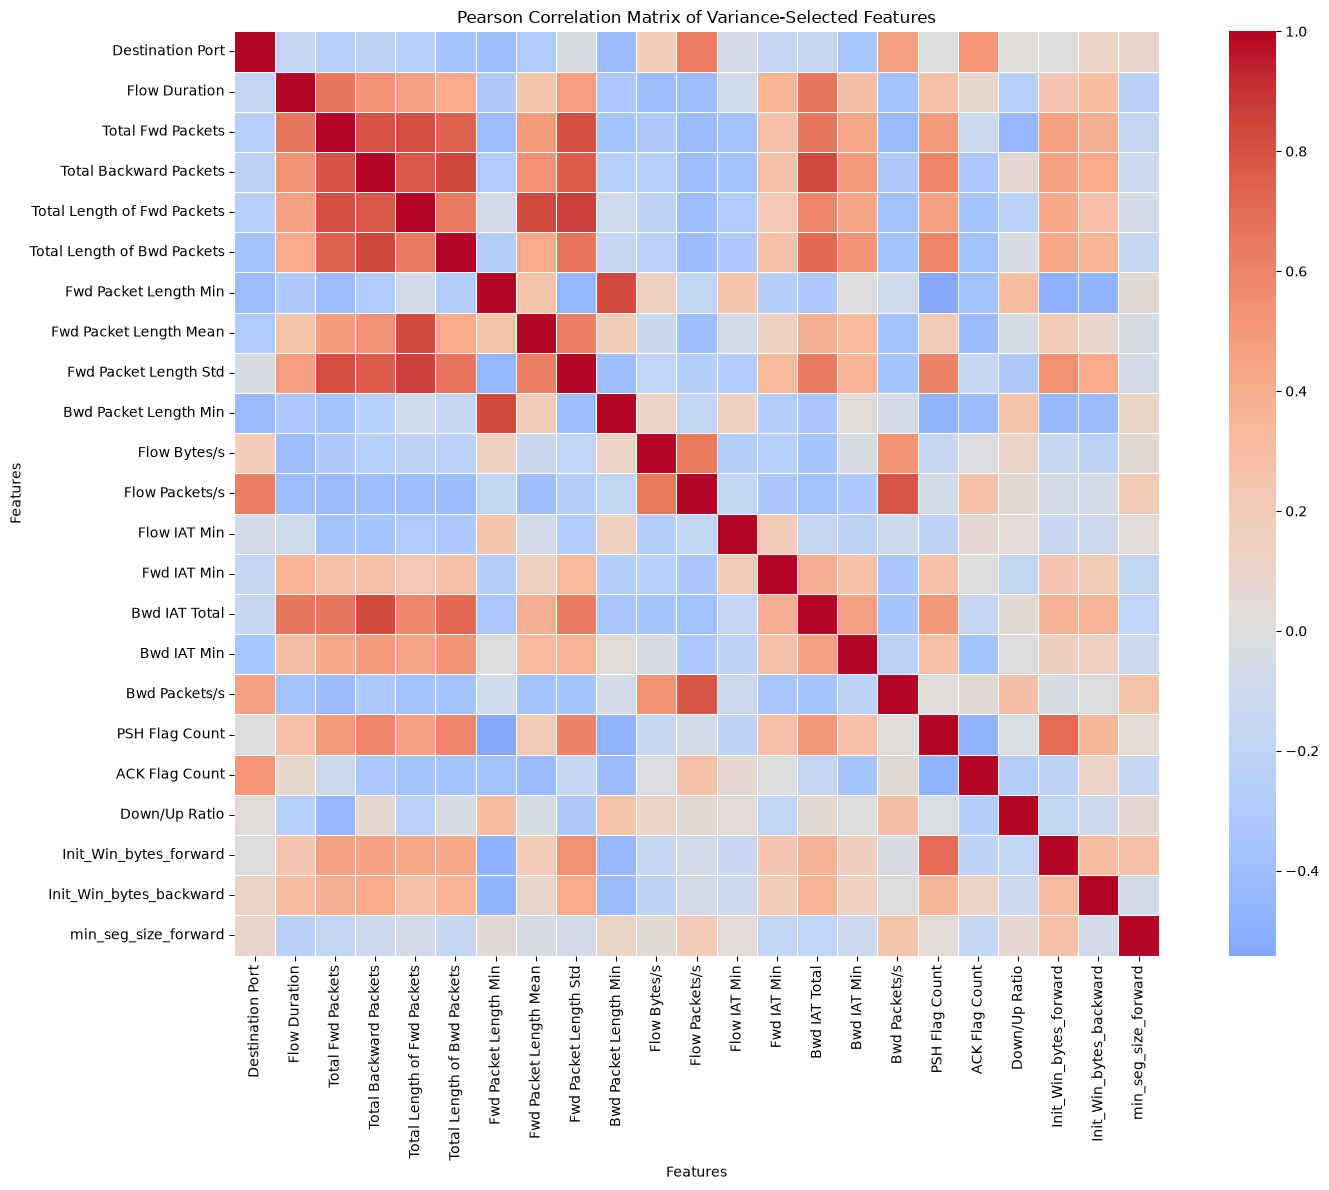

In [29]:
# Visualize the training correlation matrix

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Pearson Correlation Matrix of Variance-Selected Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

## 30. Determine Correlation-Based Feature Removals

The highly correlated feature-pair analysis is used to determine whether any features should be removed because of excessive linear redundancy.

The selected correlation threshold is an absolute Pearson correlation of **0.90**.

The analysis identified **no feature pairs** meeting or exceeding this threshold.

Therefore, no additional features will be removed during the correlation-based feature-selection stage.

All 23 features retained after variance filtering will continue to the model-based feature-selection stage.

This result demonstrates that the variance-selected feature set does not contain pairs with very strong linear correlation at the selected threshold.

In [30]:
# Determine features to remove based on the correlation analysis

correlation_removed_features = []

if not high_correlation_pairs_df.empty:
    for feature in high_correlation_pairs_df["Feature 2"]:
        if feature not in correlation_removed_features:
            correlation_removed_features.append(feature)

correlation_selected_features = [
    feature
    for feature in X_train_variance.columns
    if feature not in correlation_removed_features
]

print("CORRELATION-BASED FEATURE SELECTION")
print("=" * 70)

print("Features before correlation filtering:",
      X_train_variance.shape[1])

print("Highly correlated pairs found:",
      len(high_correlation_pairs_df))

print("Features removed:",
      len(correlation_removed_features))

print("Features retained:",
      len(correlation_selected_features))

print("\nRemoved features:")

if correlation_removed_features:
    for index, feature in enumerate(correlation_removed_features, start=1):
        print(f"{index:2d}. {feature}")
else:
    print("None")

print("\nCorrelation-based feature selection completed.")

CORRELATION-BASED FEATURE SELECTION
Features before correlation filtering: 23
Highly correlated pairs found: 0
Features removed: 0
Features retained: 23

Removed features:
None

Correlation-based feature selection completed.


## 31. Create Correlation-Selected Training Dataset

The features retained after the correlation-based analysis are used to create the correlation-selected training dataset.

Since no highly correlated feature pairs were identified at the selected absolute Pearson correlation threshold of 0.90, all 23 variance-selected features are retained.

The resulting training dataset therefore contains:

- **894,944 training observations**
- **23 selected features**

This dataset will be used as the input for the model-based feature-selection stage.

The target labels remain unchanged because feature selection only modifies the input feature space.

In [31]:
# Create the correlation-selected training dataset

X_train_correlation = X_train_variance[
    correlation_selected_features
].copy()

print("CORRELATION-SELECTED TRAINING DATASET")
print("=" * 70)

print("Training shape before correlation filtering:",
      X_train_variance.shape)

print("Training shape after correlation filtering :",
      X_train_correlation.shape)

print("\nNumber of retained features:",
      X_train_correlation.shape[1])

print("Number of removed features:",
      X_train_variance.shape[1] - X_train_correlation.shape[1])

print("\nCorrelation-selected training dataset created successfully.")

CORRELATION-SELECTED TRAINING DATASET
Training shape before correlation filtering: (894944, 23)
Training shape after correlation filtering : (894944, 23)

Number of retained features: 23
Number of removed features: 0

Correlation-selected training dataset created successfully.


## 32. Create Correlation-Selected Testing Dataset

The same feature-selection decision learned from the training dataset is applied to the testing dataset.

The `correlation_selected_features` list contains the 23 features retained after the variance and correlation-based selection stages.

Because no features were removed during correlation filtering, the testing dataset will also retain all 23 features.

The correlation analysis is not recalculated on the testing dataset. Instead, the feature-selection decision obtained from the training data is directly applied to `X_test_variance`.

This maintains consistency between the training and testing feature spaces and prevents information from the testing dataset from influencing feature selection.

In [32]:
# Create the correlation-selected testing dataset

X_test_correlation = X_test_variance[
    correlation_selected_features
].copy()

print("CORRELATION-SELECTED TESTING DATASET")
print("=" * 70)

print("Testing shape before correlation filtering:",
      X_test_variance.shape)

print("Testing shape after correlation filtering :",
      X_test_correlation.shape)

print("\nNumber of retained features:",
      X_test_correlation.shape[1])

print("Number of removed features:",
      X_test_variance.shape[1] - X_test_correlation.shape[1])

print("\nTraining and testing feature counts match:",
      X_train_correlation.shape[1] == X_test_correlation.shape[1])

print("Feature order matches:",
      X_train_correlation.columns.tolist() ==
      X_test_correlation.columns.tolist())

CORRELATION-SELECTED TESTING DATASET
Testing shape before correlation filtering: (223737, 23)
Testing shape after correlation filtering : (223737, 23)

Number of retained features: 23
Number of removed features: 0

Training and testing feature counts match: True
Feature order matches: True


## 33. Prepare Target Labels for Model-Based Feature Selection

The target labels are prepared for the model-based feature-selection stage.

The target variable is stored in the `Target_Encoded` column of `y_train`.

For Scikit-learn classification models, the target should be provided as a one-dimensional array rather than a single-column DataFrame.

Therefore, the `Target_Encoded` column is extracted from `y_train` as a Pandas Series.

Only the training target is prepared because the model-based feature-selection process will be learned exclusively from the training dataset.

The testing target will not be used to determine feature importance or the final selected feature set.

In [33]:
# Prepare the training target for model-based feature selection

y_train_fs = y_train["Target_Encoded"].copy()

print("TRAINING TARGET PREPARATION")
print("=" * 70)

print("Target shape:", y_train_fs.shape)
print("Number of training labels:", len(y_train_fs))

print("\nTarget data type:", y_train_fs.dtype)

print("\nUnique target classes:")
print(sorted(y_train_fs.unique().tolist()))

print("\nTarget preparation completed successfully.")

TRAINING TARGET PREPARATION
Target shape: (894944,)
Number of training labels: 894944

Target data type: int64

Unique target classes:
[0, 1, 2, 3]

Target preparation completed successfully.


## 34. Import Model-Based Feature Selection Tools

The required Scikit-learn components for model-based feature selection are imported in this section.

A **Random Forest Classifier** will be used to estimate the importance of each remaining feature.

Random Forest is suitable for this task because it can capture nonlinear relationships between network traffic features and the target classes.

The following components will be used:

- `RandomForestClassifier` — trains the feature-importance model.
- `SelectFromModel` — selects features according to their calculated importance.

The model used in this stage is a feature-selection model rather than the final classification model. Its purpose is to identify informative features from the 23 features remaining after variance and correlation filtering.

The model will be trained using the training dataset only.

In [34]:
# Import model-based feature selection tools

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

print("Model-based feature selection tools imported successfully!")
print("=" * 70)
print("RandomForestClassifier imported.")
print("SelectFromModel imported.")

Model-based feature selection tools imported successfully!
RandomForestClassifier imported.
SelectFromModel imported.


## 35. Configure the Random Forest Feature-Selection Model

A Random Forest Classifier is configured to estimate the importance of the 23 features remaining after variance and correlation-based selection.

The Random Forest will be used only as a **feature-importance model** at this stage. It is not the final classification model of the project.

The following configuration is used:

- **100 decision trees** using `n_estimators=100`.
- **Maximum tree depth of 20** using `max_depth=20`.
- **Balanced subsampling of classes** using `class_weight="balanced_subsample"` to account for the class imbalance in the training data.
- **All available CPU cores** using `n_jobs=-1` to improve training speed.
- **Random state of 42** to make the feature-selection process reproducible.

The model will be trained using the correlation-selected training features and the training target labels only.

The testing dataset will not be used during this model-fitting process.

In [35]:
# Configure the Random Forest feature-selection model

rf_feature_selector = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

print("RANDOM FOREST FEATURE-SELECTION MODEL")
print("=" * 70)

print("Number of trees       :", 100)
print("Maximum tree depth    :", 20)
print("Class weighting       :", "balanced_subsample")
print("Number of CPU cores   :", -1)
print("Random state          :", 42)

print("\nRandom Forest feature-selection model configured successfully.")

RANDOM FOREST FEATURE-SELECTION MODEL
Number of trees       : 100
Maximum tree depth    : 20
Class weighting       : balanced_subsample
Number of CPU cores   : -1
Random state          : 42

Random Forest feature-selection model configured successfully.


## 36. Train the Random Forest Feature-Importance Model

The configured Random Forest Classifier is trained using the correlation-selected training dataset and the prepared training target labels.

The model is trained exclusively on the training data:

- **Training observations:** 894,944
- **Input features:** 23
- **Target classes:** 4

The purpose of this model is to calculate the relative importance of each feature.

Random Forest determines feature importance based on how much each feature contributes to reducing impurity across the decision trees in the forest.

The testing dataset is not used during model training or feature-importance calculation.

This ensures that the feature-selection decision remains based only on the training data and avoids information leakage from the held-out testing dataset.

In [36]:
# Train the Random Forest feature-importance model

print("TRAINING RANDOM FOREST FEATURE-IMPORTANCE MODEL")
print("=" * 70)

print("Training samples:", X_train_correlation.shape[0])
print("Training features:", X_train_correlation.shape[1])
print("Target classes:", sorted(y_train_fs.unique().tolist()))

print("\nTraining model...")

rf_feature_selector.fit(
    X_train_correlation,
    y_train_fs
)

print("\nRandom Forest feature-importance model trained successfully!")

TRAINING RANDOM FOREST FEATURE-IMPORTANCE MODEL
Training samples: 894944
Training features: 23
Target classes: [0, 1, 2, 3]

Training model...

Random Forest feature-importance model trained successfully!


## 37. Extract Random Forest Feature Importances

After training the Random Forest feature-selection model, the importance score of each feature is extracted.

Random Forest assigns an importance value to every input feature based on its contribution to reducing impurity across the decision trees.

Higher importance values indicate that a feature contributed more strongly to the decisions made by the Random Forest model.

The feature importance values are combined with their corresponding feature names and stored in a Pandas DataFrame.

The resulting table will be sorted from highest to lowest importance so that the most informative features can be easily identified.

These importance values are calculated using the training dataset only.

In [37]:
# Extract feature importance values from the trained Random Forest

feature_importances = rf_feature_selector.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_train_correlation.columns,
    "Importance": feature_importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("RANDOM FOREST FEATURE IMPORTANCES")
print("=" * 70)

print("Number of features analyzed:",
      len(feature_importance_df))

print("\nFeature importance ranking:")
print(feature_importance_df.to_string(index=False))

RANDOM FOREST FEATURE IMPORTANCES
Number of features analyzed: 23

Feature importance ranking:
                    Feature  Importance
           Destination Port    0.121062
Total Length of Fwd Packets    0.108435
     Fwd Packet Length Mean    0.105294
     Init_Win_bytes_forward    0.070785
    Init_Win_bytes_backward    0.069157
              Flow Duration    0.064060
          Total Fwd Packets    0.056297
       min_seg_size_forward    0.052464
Total Length of Bwd Packets    0.044833
      Bwd Packet Length Min    0.036053
              Bwd Packets/s    0.034662
             PSH Flag Count    0.034235
     Total Backward Packets    0.031277
             Flow Packets/s    0.028683
               Flow Bytes/s    0.026767
      Fwd Packet Length Std    0.022749
      Fwd Packet Length Min    0.021825
             ACK Flag Count    0.018899
              Bwd IAT Total    0.016730
                Fwd IAT Min    0.015082
               Flow IAT Min    0.011709
              Down/Up Rat

## 38. Visualize Feature Importance Ranking

The Random Forest feature-importance scores are visualized to make the relative contribution of the 23 features easier to compare.

A horizontal bar chart is used because the feature names are relatively long and are easier to read in a horizontal layout.

The features are displayed from highest to lowest importance.

This visualization provides a clear overview of which network traffic characteristics contribute most strongly to the Random Forest feature-selection model.

The visualization is based entirely on feature importance values learned from the training dataset.

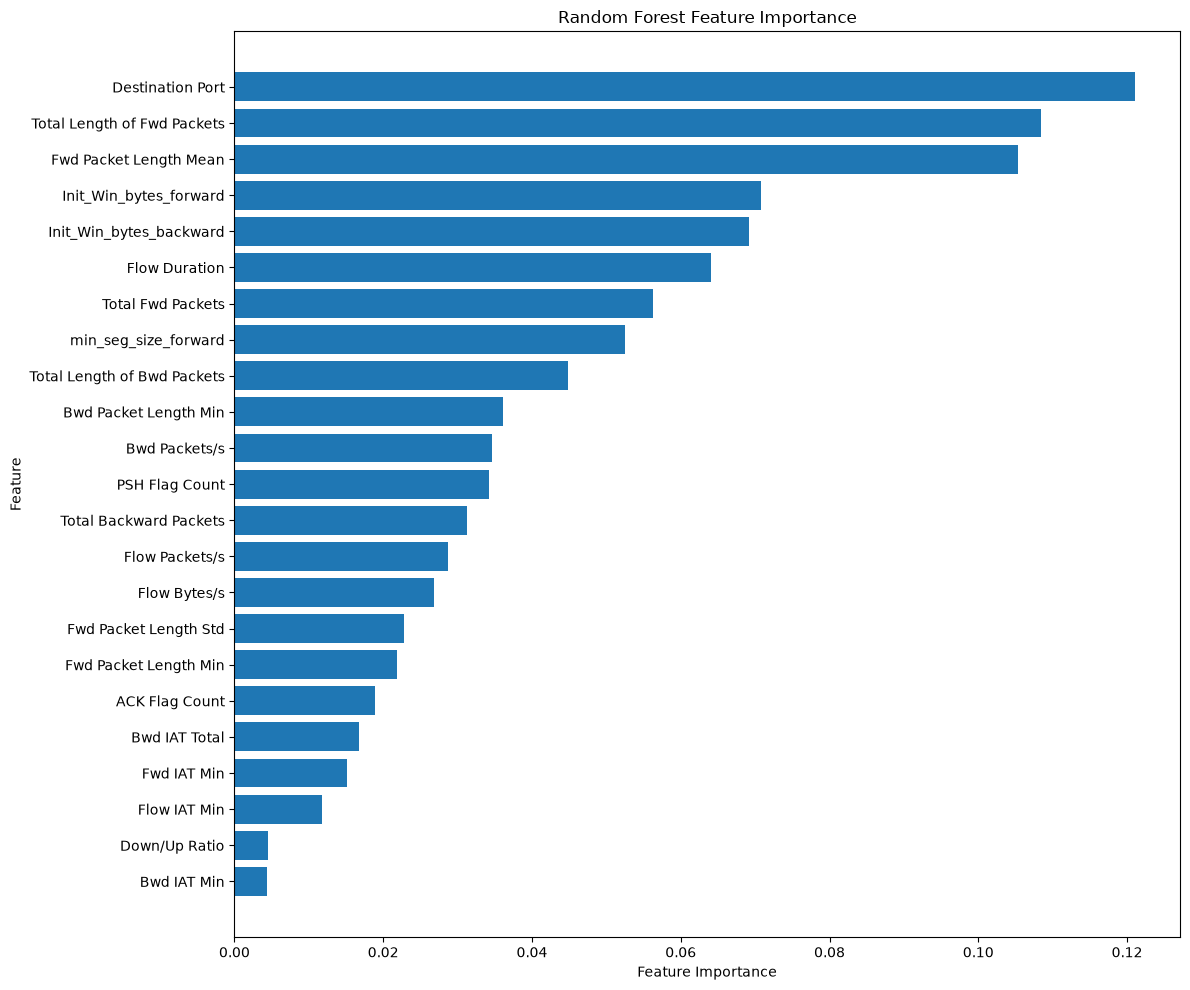

In [38]:
# Visualize Random Forest feature importance

plt.figure(figsize=(12, 10))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 39. Calculate Feature Importance Statistics

The statistical characteristics of the Random Forest feature-importance scores are examined before selecting the final feature subset.

The following values are calculated:

- **Minimum importance** — the lowest feature-importance score.
- **Maximum importance** — the highest feature-importance score.
- **Mean importance** — the average importance across all 23 features.
- **Median importance** — the middle importance value when the scores are ordered.

The median importance will later be used as the threshold for model-based feature selection.

Using the median provides a data-driven selection criterion based on the feature-importance distribution rather than manually choosing a fixed importance value.

In [39]:
# Calculate feature importance statistics

importance_min = feature_importance_df["Importance"].min()
importance_max = feature_importance_df["Importance"].max()
importance_mean = feature_importance_df["Importance"].mean()
importance_median = feature_importance_df["Importance"].median()

print("FEATURE IMPORTANCE STATISTICS")
print("=" * 70)

print(f"Number of features : {len(feature_importance_df)}")
print(f"Minimum importance : {importance_min:.6f}")
print(f"Maximum importance : {importance_max:.6f}")
print(f"Mean importance    : {importance_mean:.6f}")
print(f"Median importance  : {importance_median:.6f}")

FEATURE IMPORTANCE STATISTICS
Number of features : 23
Minimum importance : 0.004371
Maximum importance : 0.121062
Mean importance    : 0.043478
Median importance  : 0.034235


## 40. Define the Model-Based Feature Selection Threshold

The median Random Forest feature-importance value is selected as the threshold for model-based feature selection.

The calculated median importance is **0.034235**.

Features with importance values greater than or equal to this threshold will be retained, while features below the threshold will be excluded from the final feature set.

Using the median as the threshold provides a data-driven approach to reducing the feature space.

The threshold is derived exclusively from the training dataset and will not be recalculated using the testing dataset.

In [40]:
# Define the model-based feature selection threshold

model_selection_threshold = importance_median

print("MODEL-BASED FEATURE SELECTION THRESHOLD")
print("=" * 70)

print("Selection method       :", "Median feature importance")
print("Calculated threshold   :", f"{model_selection_threshold:.6f}")
print("Features >= threshold  :", "Retained")
print("Features < threshold   :", "Removed")

print("\nModel-based selection threshold defined successfully.")

MODEL-BASED FEATURE SELECTION THRESHOLD
Selection method       : Median feature importance
Calculated threshold   : 0.034235
Features >= threshold  : Retained
Features < threshold   : Removed

Model-based selection threshold defined successfully.


## 41. Apply Model-Based Feature Selection

The `SelectFromModel` method is used to select features based on the importance values generated by the trained Random Forest model.

The selection threshold is the median feature-importance value calculated in the previous section.

Features with importance values greater than or equal to the median threshold are retained, while features below the threshold are removed.

The selector is based on the already trained Random Forest model and therefore does not use the testing dataset.

The selected feature names will be extracted after applying the selector so that the same feature subset can be applied to the testing dataset.

In [41]:
# Apply SelectFromModel using the trained Random Forest

model_selector = SelectFromModel(
    estimator=rf_feature_selector,
    threshold=model_selection_threshold,
    prefit=True
)

model_support = model_selector.get_support()

model_selected_features = X_train_correlation.columns[
    model_support
].tolist()

model_removed_features = X_train_correlation.columns[
    ~model_support
].tolist()

print("MODEL-BASED FEATURE SELECTION")
print("=" * 70)

print("Features before model selection:",
      X_train_correlation.shape[1])

print("Features retained:",
      len(model_selected_features))

print("Features removed:",
      len(model_removed_features))

print("\nSelected features:")
for index, feature in enumerate(model_selected_features, start=1):
    print(f"{index:2d}. {feature}")

print("\nRemoved features:")
for index, feature in enumerate(model_removed_features, start=1):
    print(f"{index:2d}. {feature}")

MODEL-BASED FEATURE SELECTION
Features before model selection: 23
Features retained: 12
Features removed: 11

Selected features:
 1. Destination Port
 2. Flow Duration
 3. Total Fwd Packets
 4. Total Length of Fwd Packets
 5. Total Length of Bwd Packets
 6. Fwd Packet Length Mean
 7. Bwd Packet Length Min
 8. Bwd Packets/s
 9. PSH Flag Count
10. Init_Win_bytes_forward
11. Init_Win_bytes_backward
12. min_seg_size_forward

Removed features:
 1. Total Backward Packets
 2. Fwd Packet Length Min
 3. Fwd Packet Length Std
 4. Flow Bytes/s
 5. Flow Packets/s
 6. Flow IAT Min
 7. Fwd IAT Min
 8. Bwd IAT Total
 9. Bwd IAT Min
10. ACK Flag Count
11. Down/Up Ratio


## 42. Verify Selected Feature Importance

The features selected by the model-based feature-selection stage are verified against the calculated Random Forest importance scores.

The selected features should have importance values greater than or equal to the median importance threshold of **0.034235**.

The removed features should have importance values below this threshold.

This verification ensures that the `SelectFromModel` selection has been applied consistently with the defined model-based feature-selection criterion.

The verification is based exclusively on the feature importance values learned from the training dataset.

In [42]:
# Verify the importance values of selected and removed features

selected_importances = feature_importance_df[
    feature_importance_df["Feature"].isin(model_selected_features)
].copy()

removed_importances = feature_importance_df[
    feature_importance_df["Feature"].isin(model_removed_features)
].copy()

selected_meet_threshold = (
    selected_importances["Importance"] >= model_selection_threshold
).all()

removed_below_threshold = (
    removed_importances["Importance"] < model_selection_threshold
).all()

print("MODEL-BASED FEATURE SELECTION VERIFICATION")
print("=" * 70)

print("Selection threshold:",
      f"{model_selection_threshold:.6f}")

print("\nSelected features:")
print(
    selected_importances
    .sort_values(by="Importance", ascending=False)
    .to_string(index=False)
)

print("\nRemoved features:")
print(
    removed_importances
    .sort_values(by="Importance", ascending=False)
    .to_string(index=False)
)

print("\nVerification results:")
print(
    "All selected features meet threshold:",
    selected_meet_threshold
)

print(
    "All removed features are below threshold:",
    removed_below_threshold
)

if selected_meet_threshold and removed_below_threshold:
    print("\nModel-based feature-selection verification: PASSED")
else:
    print("\nModel-based feature-selection verification: FAILED")

MODEL-BASED FEATURE SELECTION VERIFICATION
Selection threshold: 0.034235

Selected features:
                    Feature  Importance
           Destination Port    0.121062
Total Length of Fwd Packets    0.108435
     Fwd Packet Length Mean    0.105294
     Init_Win_bytes_forward    0.070785
    Init_Win_bytes_backward    0.069157
              Flow Duration    0.064060
          Total Fwd Packets    0.056297
       min_seg_size_forward    0.052464
Total Length of Bwd Packets    0.044833
      Bwd Packet Length Min    0.036053
              Bwd Packets/s    0.034662
             PSH Flag Count    0.034235

Removed features:
               Feature  Importance
Total Backward Packets    0.031277
        Flow Packets/s    0.028683
          Flow Bytes/s    0.026767
 Fwd Packet Length Std    0.022749
 Fwd Packet Length Min    0.021825
        ACK Flag Count    0.018899
         Bwd IAT Total    0.016730
           Fwd IAT Min    0.015082
          Flow IAT Min    0.011709
         Down/Up R

## 43. Create Final Selected Training Dataset

The 12 features identified by the model-based feature-selection stage are used to create the final selected training dataset.

These features were selected using the following sequence:

1. Zero-variance features were removed.
2. Highly correlated features were examined using a Pearson correlation threshold of 0.90.
3. Random Forest feature importance was calculated.
4. Features with importance greater than or equal to the median importance threshold were retained.

The resulting dataset contains the original training observations but only the final selected features.

The target labels remain unchanged and continue to correspond to the training observations.

This dataset represents the final feature space that will be passed to the machine-learning model-building stage.

In [43]:
# Create the final selected training dataset

X_train_selected = X_train_correlation[
    model_selected_features
].copy()

print("FINAL SELECTED TRAINING DATASET")
print("=" * 70)

print("Training shape before model selection:",
      X_train_correlation.shape)

print("Final training shape:",
      X_train_selected.shape)

print("\nFinal number of selected features:",
      X_train_selected.shape[1])

print("Number of training observations:",
      X_train_selected.shape[0])

print("\nFinal selected features:")
for index, feature in enumerate(
    X_train_selected.columns,
    start=1
):
    print(f"{index:2d}. {feature}")

print("\nFinal selected training dataset created successfully.")

FINAL SELECTED TRAINING DATASET
Training shape before model selection: (894944, 23)
Final training shape: (894944, 12)

Final number of selected features: 12
Number of training observations: 894944

Final selected features:
 1. Destination Port
 2. Flow Duration
 3. Total Fwd Packets
 4. Total Length of Fwd Packets
 5. Total Length of Bwd Packets
 6. Fwd Packet Length Mean
 7. Bwd Packet Length Min
 8. Bwd Packets/s
 9. PSH Flag Count
10. Init_Win_bytes_forward
11. Init_Win_bytes_backward
12. min_seg_size_forward

Final selected training dataset created successfully.


## 44. Create Final Selected Testing Dataset

The final 12 features selected from the training dataset are applied to the testing dataset.

The testing dataset is not used to learn or modify the feature-selection decision.

Instead, the `model_selected_features` list obtained from the training data is used to select the identical feature columns from `X_test_correlation`.

This ensures that:

- The training and testing datasets contain the same final features.
- The feature order is identical.
- The testing data remains independent from the feature-selection learning process.

The resulting dataset contains **223,737 testing observations and 12 selected features**.

In [44]:
# Create the final selected testing dataset

X_test_selected = X_test_correlation[
    model_selected_features
].copy()

print("FINAL SELECTED TESTING DATASET")
print("=" * 70)

print("Testing shape before model selection:",
      X_test_correlation.shape)

print("Final testing shape:",
      X_test_selected.shape)

print("\nFinal number of selected features:",
      X_test_selected.shape[1])

print("Number of testing observations:",
      X_test_selected.shape[0])

print("\nTraining and testing feature counts match:",
      X_train_selected.shape[1] == X_test_selected.shape[1])

print("Feature order matches:",
      X_train_selected.columns.tolist() ==
      X_test_selected.columns.tolist())

print("\nFinal selected testing dataset created successfully.")

FINAL SELECTED TESTING DATASET
Testing shape before model selection: (223737, 23)
Final testing shape: (223737, 12)

Final number of selected features: 12
Number of testing observations: 223737

Training and testing feature counts match: True
Feature order matches: True

Final selected testing dataset created successfully.


## 45. Verify Final Train/Test Feature Consistency

The final selected training and testing datasets are compared to ensure that they contain exactly the same feature columns in the same order.

This verification is important because the machine-learning model will be trained using `X_train_selected` and later evaluated using `X_test_selected`.

The following conditions are checked:

- Both datasets contain 12 features.
- Both datasets contain the same feature names.
- The feature order is identical.
- The number of training observations remains 894,944.
- The number of testing observations remains 223,737.

A successful verification confirms that the final feature-selection process has produced compatible training and testing datasets.

In [45]:
# Verify final training and testing feature consistency

final_train_features = X_train_selected.columns.tolist()
final_test_features = X_test_selected.columns.tolist()

same_final_feature_count = (
    X_train_selected.shape[1] == X_test_selected.shape[1]
)

same_final_feature_names = (
    set(final_train_features) == set(final_test_features)
)

same_final_feature_order = (
    final_train_features == final_test_features
)

correct_train_samples = (
    X_train_selected.shape[0] == len(y_train_fs)
)

correct_test_samples = (
    X_test_selected.shape[0] == len(y_test)
)

final_feature_consistency = (
    same_final_feature_count
    and same_final_feature_names
    and same_final_feature_order
    and correct_train_samples
    and correct_test_samples
)

print("FINAL TRAIN/TEST FEATURE CONSISTENCY")
print("=" * 70)

print("Final training shape :", X_train_selected.shape)
print("Final testing shape  :", X_test_selected.shape)

print("\nSame feature count :", same_final_feature_count)
print("Same feature names :", same_final_feature_names)
print("Same feature order :", same_final_feature_order)

print("\nTraining sample count correct:",
      correct_train_samples)

print("Testing sample count correct :",
      correct_test_samples)

print(
    "\nFinal feature consistency:",
    "PASSED" if final_feature_consistency else "FAILED"
)

FINAL TRAIN/TEST FEATURE CONSISTENCY
Final training shape : (894944, 12)
Final testing shape  : (223737, 12)

Same feature count : True
Same feature names : True
Same feature order : True

Training sample count correct: True
Testing sample count correct : True

Final feature consistency: PASSED


## 46. Verify Final Dataset Missing and Infinite Values

The final selected training and testing datasets are checked for missing and infinite values.

Feature selection should not introduce missing or infinite values into the datasets.

The following conditions are verified:

- Number of missing values in the final training dataset.
- Number of missing values in the final testing dataset.
- Number of infinite values in the final training dataset.
- Number of infinite values in the final testing dataset.

A successful validation should show zero missing values and zero infinite values in both final datasets.

This is a validation step only. No additional data transformation is performed.

In [46]:
# Verify missing and infinite values in the final selected datasets

final_train_missing = X_train_selected.isnull().sum().sum()
final_test_missing = X_test_selected.isnull().sum().sum()

final_train_infinite = np.isinf(
    X_train_selected.to_numpy()
).sum()

final_test_infinite = np.isinf(
    X_test_selected.to_numpy()
).sum()

final_data_quality = (
    final_train_missing == 0
    and final_test_missing == 0
    and final_train_infinite == 0
    and final_test_infinite == 0
)

print("FINAL DATA QUALITY VERIFICATION")
print("=" * 70)

print("Training missing values :", final_train_missing)
print("Testing missing values  :", final_test_missing)

print("Training infinite values:", final_train_infinite)
print("Testing infinite values :", final_test_infinite)

print(
    "\nFinal data quality:",
    "PASSED" if final_data_quality else "FAILED"
)

FINAL DATA QUALITY VERIFICATION
Training missing values : 0
Testing missing values  : 0
Training infinite values: 0
Testing infinite values : 0

Final data quality: PASSED


## 47. Verify Final Target Alignment

The final selected feature datasets are checked against their corresponding target labels to ensure that the observations remain correctly aligned after feature selection.

Feature selection changes only the number of input columns. It must not change the number or ordering of observations.

The following conditions are verified:

- The number of rows in `X_train_selected` matches the number of labels in `y_train`.
- The number of rows in `X_test_selected` matches the number of labels in `y_test`.
- The training target still contains the four expected encoded classes.
- The testing target still contains the four expected encoded classes.

A successful verification confirms that the final selected feature datasets remain correctly aligned with their target labels.

In [47]:
# Verify alignment between final features and target labels

train_row_alignment = (
    X_train_selected.shape[0] == len(y_train)
)

test_row_alignment = (
    X_test_selected.shape[0] == len(y_test)
)

train_classes_valid = (
    sorted(y_train_fs.unique().tolist()) == [0, 1, 2, 3]
)

test_classes_valid = (
    sorted(y_test["Target_Encoded"].unique().tolist())
    == [0, 1, 2, 3]
)

target_alignment_valid = (
    train_row_alignment
    and test_row_alignment
    and train_classes_valid
    and test_classes_valid
)

print("FINAL TARGET ALIGNMENT VERIFICATION")
print("=" * 70)

print("Training feature rows :", X_train_selected.shape[0])
print("Training target rows  :", len(y_train))
print("Training rows match   :", train_row_alignment)

print("\nTesting feature rows  :", X_test_selected.shape[0])
print("Testing target rows   :", len(y_test))
print("Testing rows match    :", test_row_alignment)

print("\nTraining classes valid:",
      train_classes_valid)

print("Testing classes valid :",
      test_classes_valid)

print(
    "\nFinal target alignment:",
    "PASSED" if target_alignment_valid else "FAILED"
)

FINAL TARGET ALIGNMENT VERIFICATION
Training feature rows : 894944
Training target rows  : 894944
Training rows match   : True

Testing feature rows  : 223737
Testing target rows   : 223737
Testing rows match    : True

Training classes valid: True
Testing classes valid : True

Final target alignment: PASSED


## 48. Calculate Overall Feature Reduction

The overall dimensionality reduction achieved by the complete feature-selection pipeline is calculated.

The feature-selection process started with **37 preprocessed features** and produced a final feature set containing **12 features**.

The reduction is calculated as:

- Initial feature count: 37
- Final feature count: 12
- Number of features removed: 25
- Overall reduction percentage: approximately 67.57%

This calculation provides a quantitative measure of how much the feature space was reduced while retaining the features selected by the model-based feature-selection stage.

In [48]:
# Calculate overall feature reduction

initial_count = len(initial_features)
final_count = len(model_selected_features)

features_removed_overall = initial_count - final_count

reduction_percentage = (
    features_removed_overall / initial_count
) * 100

retained_percentage = (
    final_count / initial_count
) * 100

print("OVERALL FEATURE REDUCTION")
print("=" * 70)

print("Initial number of features :", initial_count)
print("Final number of features   :", final_count)
print("Features removed           :", features_removed_overall)

print(
    "Overall reduction          :",
    f"{reduction_percentage:.2f}%"
)

print(
    "Features retained          :",
    f"{retained_percentage:.2f}%"
)

OVERALL FEATURE REDUCTION
Initial number of features : 37
Final number of features   : 12
Features removed           : 25
Overall reduction          : 67.57%
Features retained          : 32.43%


## 49. Compare Feature Counts Across Feature-Selection Stages

The number of features remaining after each feature-selection stage is compared to understand how the dimensionality changed throughout the pipeline.

The feature-selection process consists of three stages:

1. **Initial preprocessed feature set** — 37 features.
2. **Variance-based selection** — 23 features remain after removing 14 zero-variance features.
3. **Correlation-based selection** — 23 features remain because no feature pairs exceeded the absolute Pearson correlation threshold of 0.90.
4. **Model-based selection** — 12 features remain after applying the median Random Forest feature-importance threshold.

This comparison provides a clear summary of the contribution of each feature-selection technique to the overall dimensionality reduction.

In [49]:
# Compare feature counts across all feature-selection stages

feature_selection_stages = pd.DataFrame({
    "Stage": [
        "Initial Features",
        "After Variance Selection",
        "After Correlation Selection",
        "After Model-Based Selection"
    ],
    "Feature Count": [
        len(initial_features),
        len(variance_selected_features),
        len(correlation_selected_features),
        len(model_selected_features)
    ]
})

feature_selection_stages["Features Removed From Previous Stage"] = (
    feature_selection_stages["Feature Count"]
    .shift(1)
    - feature_selection_stages["Feature Count"]
).fillna(0).astype(int)

print("FEATURE COUNT COMPARISON")
print("=" * 80)

print(feature_selection_stages.to_string(index=False))

FEATURE COUNT COMPARISON
                      Stage  Feature Count  Features Removed From Previous Stage
           Initial Features             37                                     0
   After Variance Selection             23                                    14
After Correlation Selection             23                                     0
After Model-Based Selection             12                                    11


## 50. Create Feature-Selection Summary Table

A consolidated summary table is created to document the complete feature-selection process.

The table records the number of features available at each stage and the number of features removed during that stage.

The feature-selection pipeline consists of:

1. Initial preprocessed features.
2. Variance-based feature selection.
3. Correlation-based feature selection.
4. Model-based feature selection.

This summary provides a compact representation of the dimensionality-reduction process and can be used later when documenting the methodology and results of the project.

In [50]:
# Create a consolidated feature-selection summary table

feature_selection_summary = pd.DataFrame({
    "Stage": [
        "Initial Preprocessed Features",
        "Variance-Based Selection",
        "Correlation-Based Selection",
        "Model-Based Selection"
    ],
    "Features Before": [
        initial_count,
        initial_count,
        len(variance_selected_features),
        len(correlation_selected_features)
    ],
    "Features Removed": [
        0,
        len(variance_removed_features),
        len(correlation_removed_features),
        len(model_removed_features)
    ],
    "Features After": [
        initial_count,
        len(variance_selected_features),
        len(correlation_selected_features),
        len(model_selected_features)
    ]
})

print("FEATURE-SELECTION SUMMARY TABLE")
print("=" * 90)

print(feature_selection_summary.to_string(index=False))

FEATURE-SELECTION SUMMARY TABLE
                        Stage  Features Before  Features Removed  Features After
Initial Preprocessed Features               37                 0              37
     Variance-Based Selection               37                14              23
  Correlation-Based Selection               23                 0              23
        Model-Based Selection               23                11              12


## 51. Display Final Selected Feature Importance Ranking

The final 12 selected features are displayed together with their Random Forest feature-importance scores.

These features were selected because their importance values were greater than or equal to the median feature-importance threshold of **0.034235**.

The ranking is ordered from the highest importance to the lowest importance.

This table provides a clear record of the features that will be used in the subsequent machine-learning model-building stage.

In [51]:
# Display the final selected features and their importance scores

final_selected_importance_df = feature_importance_df[
    feature_importance_df["Feature"].isin(model_selected_features)
].copy()

final_selected_importance_df = final_selected_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("FINAL SELECTED FEATURE IMPORTANCE RANKING")
print("=" * 80)

print(
    final_selected_importance_df.to_string(
        index=False,
        formatters={
            "Importance": "{:.6f}".format
        }
    )
)

FINAL SELECTED FEATURE IMPORTANCE RANKING
                    Feature Importance
           Destination Port   0.121062
Total Length of Fwd Packets   0.108435
     Fwd Packet Length Mean   0.105294
     Init_Win_bytes_forward   0.070785
    Init_Win_bytes_backward   0.069157
              Flow Duration   0.064060
          Total Fwd Packets   0.056297
       min_seg_size_forward   0.052464
Total Length of Bwd Packets   0.044833
      Bwd Packet Length Min   0.036053
              Bwd Packets/s   0.034662
             PSH Flag Count   0.034235


## 52. Visualize Final Selected Feature Importance

The Random Forest importance scores of the 12 final selected features are visualized using a horizontal bar chart.

The features are displayed from the highest importance to the lowest importance.

This visualization makes it easier to compare the relative importance of the final selected features and provides a clear graphical representation of the features that will be used in the model-building stage.

The visualization is based exclusively on the feature-importance scores calculated from the training dataset.

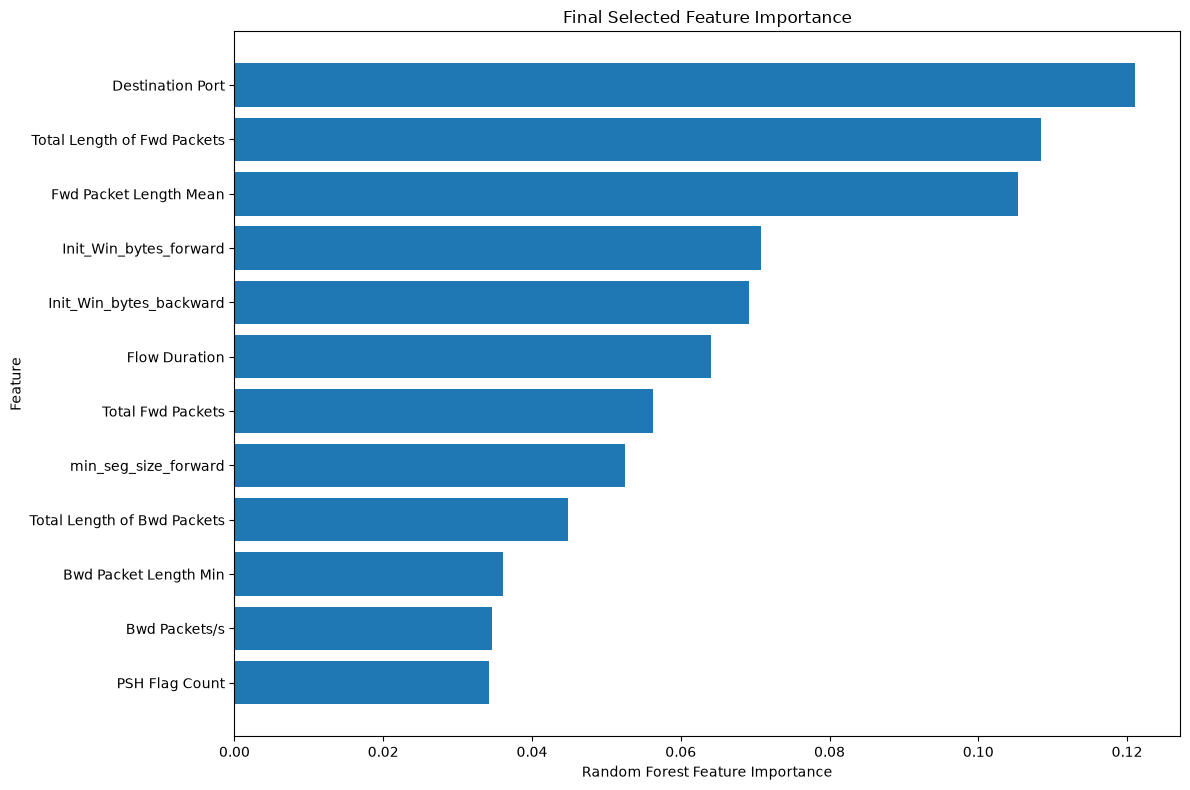

In [52]:
# Visualize final selected feature importance

plt.figure(figsize=(12, 8))

plt.barh(
    final_selected_importance_df["Feature"],
    final_selected_importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Final Selected Feature Importance")
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 50. Create Feature-Selection Summary Table

A consolidated summary table is created to document the complete feature-selection process.

The table records the number of features available before and after each feature-selection technique and the number of features removed during each stage.

The feature-selection pipeline consists of:

1. Initial preprocessed features.
2. Variance-based feature selection.
3. Correlation-based feature selection.
4. Model-based feature selection.

This summary provides a compact representation of the dimensionality-reduction process and can be used later when documenting the methodology and results of the project.

In [53]:
# Create a consolidated feature-selection summary table

feature_selection_summary = pd.DataFrame({
    "Stage": [
        "Initial Preprocessed Features",
        "Variance-Based Selection",
        "Correlation-Based Selection",
        "Model-Based Selection"
    ],
    "Features Before": [
        initial_count,
        initial_count,
        len(variance_selected_features),
        len(correlation_selected_features)
    ],
    "Features Removed": [
        0,
        len(variance_removed_features),
        len(correlation_removed_features),
        len(model_removed_features)
    ],
    "Features After": [
        initial_count,
        len(variance_selected_features),
        len(correlation_selected_features),
        len(model_selected_features)
    ]
})

print("FEATURE-SELECTION SUMMARY TABLE")
print("=" * 90)

print(feature_selection_summary.to_string(index=False))

FEATURE-SELECTION SUMMARY TABLE
                        Stage  Features Before  Features Removed  Features After
Initial Preprocessed Features               37                 0              37
     Variance-Based Selection               37                14              23
  Correlation-Based Selection               23                 0              23
        Model-Based Selection               23                11              12


## 53. Create Final Target Datasets

Feature selection changes only the input feature space and does not modify the target labels.

Therefore, the original training and testing target datasets are copied to create the final target datasets corresponding to the selected feature datasets.

The final datasets will contain:

- `X_train_selected` — 894,944 observations × 12 selected features.
- `X_test_selected` — 223,737 observations × 12 selected features.
- `y_train_selected` — 894,944 target labels.
- `y_test_selected` — 223,737 target labels.

The target column remains `Target_Encoded`.

Creating these final target datasets ensures that the selected training and testing features have corresponding target-label datasets ready for the model-building stage.

In [54]:
# Create final target datasets corresponding to the selected features

y_train_selected = y_train.copy()
y_test_selected = y_test.copy()

print("FINAL TARGET DATASETS")
print("=" * 70)

print("y_train_selected shape:", y_train_selected.shape)
print("y_test_selected shape :", y_test_selected.shape)

print("\nTarget column:")
print(y_train_selected.columns.tolist())

print("\nTraining target classes:",
      sorted(y_train_selected["Target_Encoded"].unique().tolist()))

print("Testing target classes :",
      sorted(y_test_selected["Target_Encoded"].unique().tolist()))

print("\nFinal target datasets created successfully.")

FINAL TARGET DATASETS
y_train_selected shape: (894944, 1)
y_test_selected shape : (223737, 1)

Target column:
['Target_Encoded']

Training target classes: [0, 1, 2, 3]
Testing target classes : [0, 1, 2, 3]

Final target datasets created successfully.


## 54. Validate Complete Final Dataset Structure

The complete final feature-selection datasets are validated before they are saved for use in the model-building stage.

The validation checks the final training and testing feature datasets together with their corresponding target datasets.

The following conditions are verified:

- `X_train_selected` contains 894,944 observations and 12 features.
- `X_test_selected` contains 223,737 observations and 12 features.
- `y_train_selected` contains 894,944 target labels.
- `y_test_selected` contains 223,737 target labels.
- Training feature rows match training target rows.
- Testing feature rows match testing target rows.
- Training and testing contain the same 12 features in the same order.
- No missing values are present.
- No infinite values are present.

A successful validation confirms that the final feature-selected datasets are structurally ready for the model-building stage.

In [55]:
# Complete validation of the final selected datasets

train_shape_valid = X_train_selected.shape == (894944, 12)
test_shape_valid = X_test_selected.shape == (223737, 12)

train_target_valid = y_train_selected.shape == (894944, 1)
test_target_valid = y_test_selected.shape == (223737, 1)

train_alignment_valid = (
    X_train_selected.shape[0] == y_train_selected.shape[0]
)

test_alignment_valid = (
    X_test_selected.shape[0] == y_test_selected.shape[0]
)

feature_consistency_valid = (
    X_train_selected.columns.tolist()
    == X_test_selected.columns.tolist()
)

missing_values_valid = (
    X_train_selected.isnull().sum().sum() == 0
    and X_test_selected.isnull().sum().sum() == 0
)

infinite_values_valid = (
    np.isinf(X_train_selected.to_numpy()).sum() == 0
    and np.isinf(X_test_selected.to_numpy()).sum() == 0
)

complete_validation = (
    train_shape_valid
    and test_shape_valid
    and train_target_valid
    and test_target_valid
    and train_alignment_valid
    and test_alignment_valid
    and feature_consistency_valid
    and missing_values_valid
    and infinite_values_valid
)

print("COMPLETE FINAL DATASET VALIDATION")
print("=" * 80)

print("Training feature shape valid :", train_shape_valid)
print("Testing feature shape valid  :", test_shape_valid)

print("Training target shape valid  :", train_target_valid)
print("Testing target shape valid   :", test_target_valid)

print("\nTraining feature/target alignment:",
      train_alignment_valid)

print("Testing feature/target alignment :",
      test_alignment_valid)

print("\nTrain/test feature consistency:",
      feature_consistency_valid)

print("Missing-value check:",
      missing_values_valid)

print("Infinite-value check:",
      infinite_values_valid)

print(
    "\nCOMPLETE FINAL DATASET VALIDATION:",
    "PASSED" if complete_validation else "FAILED"
)

COMPLETE FINAL DATASET VALIDATION
Training feature shape valid : True
Testing feature shape valid  : True
Training target shape valid  : True
Testing target shape valid   : True

Training feature/target alignment: True
Testing feature/target alignment : True

Train/test feature consistency: True
Missing-value check: True
Infinite-value check: True

COMPLETE FINAL DATASET VALIDATION: PASSED


## 55. Define Output File Paths

The output paths for the final feature-selected datasets are defined.

The selected datasets will be stored in the `data/processed` directory so they can be directly used by the subsequent model-building notebook.

The following files will be created:

- `selected_features.csv` — list of the 12 final selected features and their importance scores.
- `X_train_selected.csv` — final training features.
- `X_test_selected.csv` — final testing features.
- `y_train_selected.csv` — final training target labels.
- `y_test_selected.csv` — final testing target labels.

All output files are generated from the feature-selection results obtained using the training data.

In [56]:
# Define output paths for final feature-selected datasets

selected_features_path = os.path.join(
    processed_dir,
    "selected_features.csv"
)

X_train_selected_path = os.path.join(
    processed_dir,
    "X_train_selected.csv"
)

X_test_selected_path = os.path.join(
    processed_dir,
    "X_test_selected.csv"
)

y_train_selected_path = os.path.join(
    processed_dir,
    "y_train_selected.csv"
)

y_test_selected_path = os.path.join(
    processed_dir,
    "y_test_selected.csv"
)

output_files = {
    "Selected Features": selected_features_path,
    "X_train_selected": X_train_selected_path,
    "X_test_selected": X_test_selected_path,
    "y_train_selected": y_train_selected_path,
    "y_test_selected": y_test_selected_path
}

print("OUTPUT FILE PATHS")
print("=" * 80)

for name, path in output_files.items():
    print(f"{name:<22}: {path}")

print("\nOutput paths defined successfully.")

OUTPUT FILE PATHS
Selected Features     : ../data/processed/selected_features.csv
X_train_selected      : ../data/processed/X_train_selected.csv
X_test_selected       : ../data/processed/X_test_selected.csv
y_train_selected      : ../data/processed/y_train_selected.csv
y_test_selected       : ../data/processed/y_test_selected.csv

Output paths defined successfully.


## 56. Prepare the Final Selected Feature List

The final selected feature names and their Random Forest importance scores are prepared in a dedicated DataFrame.

This table provides a permanent record of the 12 features selected during the model-based feature-selection stage.

The features are ordered from highest to lowest Random Forest importance.

The resulting table will be saved as `selected_features.csv` so that the selected feature information can be reused in later stages of the project without repeating the feature-selection process.

In [57]:
# Prepare the final selected feature list for saving

selected_features_to_save = final_selected_importance_df.copy()

selected_features_to_save.insert(
    0,
    "Selection Rank",
    range(1, len(selected_features_to_save) + 1)
)

print("FINAL SELECTED FEATURE LIST")
print("=" * 90)

print(
    selected_features_to_save.to_string(
        index=False,
        formatters={
            "Importance": "{:.6f}".format
        }
    )
)

print("\nNumber of selected features:",
      len(selected_features_to_save))

print("\nFeature list prepared successfully.")

FINAL SELECTED FEATURE LIST
 Selection Rank                     Feature Importance
              1            Destination Port   0.121062
              2 Total Length of Fwd Packets   0.108435
              3      Fwd Packet Length Mean   0.105294
              4      Init_Win_bytes_forward   0.070785
              5     Init_Win_bytes_backward   0.069157
              6               Flow Duration   0.064060
              7           Total Fwd Packets   0.056297
              8        min_seg_size_forward   0.052464
              9 Total Length of Bwd Packets   0.044833
             10       Bwd Packet Length Min   0.036053
             11               Bwd Packets/s   0.034662
             12              PSH Flag Count   0.034235

Number of selected features: 12

Feature list prepared successfully.


In [58]:
# Save and verify all final feature-selection outputs

# 1. Save final selected feature list
selected_features_to_save.to_csv(
    selected_features_path,
    index=False
)

# 2. Save final selected training and testing features
X_train_selected.to_csv(
    X_train_selected_path,
    index=False
)

X_test_selected.to_csv(
    X_test_selected_path,
    index=False
)

# 3. Save final target datasets
y_train_selected.to_csv(
    y_train_selected_path,
    index=False
)

y_test_selected.to_csv(
    y_test_selected_path,
    index=False
)

# 4. Verify that all files were successfully created
print("FINAL OUTPUT FILE VERIFICATION")
print("=" * 80)

for file_name, file_path in output_files.items():
    exists = os.path.exists(file_path)
    print(f"{file_name:<25} : {'Saved Successfully' if exists else 'Not Found'}")

# 5. Reload saved datasets for final verification
X_train_check = pd.read_csv(X_train_selected_path)
X_test_check = pd.read_csv(X_test_selected_path)
y_train_check = pd.read_csv(y_train_selected_path)
y_test_check = pd.read_csv(y_test_selected_path)
selected_features_check = pd.read_csv(selected_features_path)

print("\nFINAL DATASET SHAPES")
print("=" * 80)
print("X_train_selected :", X_train_check.shape)
print("X_test_selected  :", X_test_check.shape)
print("y_train_selected :", y_train_check.shape)
print("y_test_selected  :", y_test_check.shape)
print("Selected features :", selected_features_check.shape)

# 6. Final consistency checks
print("\nFINAL VALIDATION")
print("=" * 80)

print(
    "Train/Test feature names match:",
    list(X_train_check.columns) == list(X_test_check.columns)
)

print(
    "Training feature count:",
    X_train_check.shape[1]
)

print(
    "Testing feature count:",
    X_test_check.shape[1]
)

print(
    "Missing values:",
    X_train_check.isna().sum().sum()
    + X_test_check.isna().sum().sum()
    + y_train_check.isna().sum().sum()
    + y_test_check.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(X_train_check.select_dtypes(include=np.number)).sum().sum()
    + np.isinf(X_test_check.select_dtypes(include=np.number)).sum().sum()
)

print("\nAll final feature-selection outputs saved and verified successfully.")

FINAL OUTPUT FILE VERIFICATION
Selected Features         : Saved Successfully
X_train_selected          : Saved Successfully
X_test_selected           : Saved Successfully
y_train_selected          : Saved Successfully
y_test_selected           : Saved Successfully

FINAL DATASET SHAPES
X_train_selected : (894944, 12)
X_test_selected  : (223737, 12)
y_train_selected : (894944, 1)
y_test_selected  : (223737, 1)
Selected features : (12, 3)

FINAL VALIDATION
Train/Test feature names match: True
Training feature count: 12
Testing feature count: 12
Missing values: 0
Infinite values: 0

All final feature-selection outputs saved and verified successfully.


# 59. Final Feature Selection Summary & Conclusion

## 🎯 Objective

The objective of this notebook was to perform systematic **feature selection** on the preprocessed CIC-IDS2017 network intrusion detection dataset and obtain a compact set of informative features for machine-learning model development.

The feature-selection process was designed to reduce dimensionality, remove unnecessary features, minimize redundancy, and retain features that provide useful information for distinguishing between the four network traffic classes.

---

## 🔄 Complete Feature Selection Pipeline

```mermaid
flowchart TD

A["Preprocessed CIC-IDS2017 Dataset<br/>894,944 Training Samples<br/>223,737 Testing Samples<br/>37 Features"]

B["Data Validation<br/>✓ Missing Values = 0<br/>✓ Infinite Values = 0<br/>✓ Numeric Features<br/>✓ Train/Test Consistency"]

C["Variance-Based Selection<br/>Threshold = 0.0<br/>14 Zero-Variance Features Removed"]

D["23 Features Remaining"]

E["Correlation-Based Selection<br/>Pearson Correlation<br/>Threshold = |r| ≥ 0.90"]

F["No Highly Correlated Features Removed<br/>23 Features Remaining"]

G["Random Forest Feature Importance<br/>100 Trees<br/>Balanced Subsample<br/>Training Data Only"]

H["Median Importance Threshold<br/>0.034235"]

I["11 Low-Importance Features Removed"]

J["Final Selected Feature Set<br/>12 Features"]

K["Apply Same 12 Features<br/>to Training and Testing Data"]

L["Final Model-Ready Dataset<br/>X_train: 894,944 × 12<br/>X_test: 223,737 × 12"]

A --> B
B --> C
C --> D
D --> E
E --> F
F --> G
G --> H
H --> I
I --> J
J --> K
K --> L
```

---

## 📊 Feature Reduction Summary

| Feature Selection Stage       | Features Before | Features Removed | Features After |
| ----------------------------- | --------------: | ---------------: | -------------: |
| Initial Preprocessed Features |              37 |                0 |         **37** |
| Variance-Based Selection      |              37 |           **14** |         **23** |
| Correlation-Based Selection   |              23 |            **0** |         **23** |
| Model-Based Selection         |              23 |           **11** |         **12** |
| **Overall Reduction**         |          **37** |           **25** |         **12** |

### 📉 Overall Dimensionality Reduction

**37 → 12 Features**

**25 features removed**

**67.57% overall reduction**

**32.43% of the original features retained**

---

## 🧠 Feature Selection Techniques Applied

### 1️⃣ Variance-Based Feature Selection

A variance threshold of **0.0** was applied to identify features with no variation across the training observations.

* Initial features: **37**
* Zero-variance features removed: **14**
* Remaining features: **23**

Zero-variance features were removed because they provide no variation and therefore cannot contribute useful discriminative information to the predictive model.

---

### 2️⃣ Correlation-Based Feature Selection

The remaining 23 features were analyzed using the **Pearson correlation coefficient**.

A threshold of:

> **|r| ≥ 0.90**

was used to identify highly correlated feature pairs.

Result:

* Features analyzed: **23**
* Highly correlated pairs requiring removal: **0**
* Features removed: **0**
* Features remaining: **23**

Therefore, no additional features were removed during this stage.

---

### 3️⃣ Model-Based Feature Selection

A **Random Forest classifier** was used to estimate the relative importance of the remaining 23 features.

The feature-selection Random Forest was configured with:

| Parameter           | Value                    |
| ------------------- | ------------------------ |
| Model               | Random Forest Classifier |
| Number of Trees     | 100                      |
| Maximum Depth       | 20                       |
| Class Weight        | `balanced_subsample`     |
| Random State        | 42                       |
| Parallel Processing | `n_jobs=-1`              |

The median feature-importance score was used as the selection threshold:

> **Median Importance = 0.034235**

Features with importance values greater than or equal to this threshold were retained.

Result:

* Features before model selection: **23**
* Features selected: **12**
* Features removed: **11**

---

## ⭐ Final Selected Features

| Rank | Selected Feature                | Random Forest Importance |
| ---: | ------------------------------- | -----------------------: |
|    1 | **Destination Port**            |                 0.121062 |
|    2 | **Total Length of Fwd Packets** |                 0.108435 |
|    3 | **Fwd Packet Length Mean**      |                 0.105294 |
|    4 | **Init_Win_bytes_forward**      |                 0.070785 |
|    5 | **Init_Win_bytes_backward**     |                 0.069157 |
|    6 | **Flow Duration**               |                 0.064060 |
|    7 | **Total Fwd Packets**           |                 0.056297 |
|    8 | **min_seg_size_forward**        |                 0.052464 |
|    9 | **Total Length of Bwd Packets** |                 0.044833 |
|   10 | **Bwd Packet Length Min**       |                 0.036053 |
|   11 | **Bwd Packets/s**               |                 0.034662 |
|   12 | **PSH Flag Count**              |                 0.034235 |

---

## 🔐 Data Leakage Prevention

A major methodological requirement of this notebook was to prevent **data leakage**.

```mermaid
flowchart LR

A["Training Data"] --> B["Learn Feature Selection Decisions"]

B --> C["Variance Analysis"]
B --> D["Correlation Analysis"]
B --> E["Random Forest Importance"]

C --> F["Final 12 Features"]
D --> F
E --> F

F --> G["Apply Same Feature Set"]

G --> H["Training Data"]
G --> I["Held-Out Testing Data"]

I -.->|"Not used to learn selection"| B
```

All data-dependent feature-selection decisions were learned from the **training dataset only**.

The testing dataset was not used to determine:

* Variance thresholds
* Correlation-based feature removals
* Random Forest feature importance
* Final feature-selection threshold
* Final selected feature set

After the final 12 features were determined, the **same feature names and feature order** were applied to the testing dataset.

This ensures that the testing dataset remains independent for the later model-evaluation stage.

---

## ✅ Final Dataset Validation

The final feature-selected datasets were validated before being passed to the model-building stage.

| Validation Check          | Result             |
| ------------------------- | ------------------ |
| Training feature shape    | **894,944 × 12**   |
| Testing feature shape     | **223,737 × 12**   |
| Training target shape     | **894,944 × 1**    |
| Testing target shape      | **223,737 × 1**    |
| Train/Test feature names  | ✅ Same             |
| Train/Test feature order  | ✅ Same             |
| Training target alignment | ✅ Passed           |
| Testing target alignment  | ✅ Passed           |
| Missing values            | **0**              |
| Infinite values           | **0**              |
| Target classes            | **4 (0, 1, 2, 3)** |
| Final validation          | **✅ PASSED**       |

---

## 📁 Final Output Files

The finalized feature-selection outputs were saved in:

```text
data/processed/
│
├── selected_features.csv
├── X_train_selected.csv
├── X_test_selected.csv
├── y_train_selected.csv
└── y_test_selected.csv
```

These files contain the finalized feature-selected datasets required for the next stage of the machine-learning pipeline.

---

## 🏁 Final Conclusion

The feature-selection stage successfully transformed the preprocessed CIC-IDS2017 dataset from **37 input features into a compact set of 12 informative features**.

The process combined three complementary techniques:

**Variance Analysis → Correlation Analysis → Random Forest Feature Importance**

This resulted in the removal of **25 features**, corresponding to a **67.57% reduction in dimensionality**.

The variance-based method removed features with no variation, while the correlation analysis confirmed that no additional features needed to be removed because none exceeded the selected correlation threshold. The Random Forest model then identified the most informative features based on their contribution to classification.

The final 12 features preserve the most important network-traffic characteristics identified by the feature-selection model, including packet lengths, flow duration, packet rates, TCP window information, destination port, and PSH flag information.

Throughout the process, feature-selection decisions were learned exclusively from the training data to prevent data leakage. The final selected feature set was then consistently applied to both training and testing datasets.

The final datasets were validated for **shape, feature consistency, target alignment, missing values, infinite values, and class representation**, with all validation checks successfully passed.

### 🏆 Final Result

```text
37 Initial Features
        ↓
14 Zero-Variance Features Removed
        ↓
23 Features
        ↓
0 Correlation-Based Features Removed
        ↓
23 Features
        ↓
11 Low-Importance Features Removed
        ↓
12 Final Selected Features
        ↓
67.57% Dimensionality Reduction
        ↓
Model-Ready Dataset
```

**The final 12-feature datasets are ready for the next stage:**

### 🚀 Notebook 04 — Model Building
